In [253]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [254]:
import platform, matplotlib as mpl
from matplotlib.font_manager import FontProperties, findfont

def first_ok(cands):
    for name in cands:
        try:
            findfont(FontProperties(family=name), fallback_to_default=False)
            return name
        except Exception:
            pass
    return None

sys = platform.system()
if sys == "Darwin":   # macOS
    cjk_candidates = ["Songti SC", "Hiragino Sans GB", "STHeiti", "PingFang SC",   ]
elif sys == "Windows":
    cjk_candidates = ["Microsoft YaHei", "SimHei", "NSimSun", "KaiTi"]
else:                 # Linux
    cjk_candidates = ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei", "AR PL UMing CN"]

cjk = first_ok(cjk_candidates)

#（可选）清理字体缓存，改完配置后建议重启 kernel
# import shutil; shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

mpl.rcParams.update({
    # 关键顺序：STIX（英文/数学） → DejaVu Sans（含 U+2212） → 中文
    "font.family": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),
    "font.sans-serif": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),

    # 数学字体固定用 STIX，防止落到“default”
    "mathtext.fontset": "stix",
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",

    "axes.unicode_minus": True,   # 使用 Unicode '−'（由 STIX/DejaVu 提供）
    "text.usetex": False,         # 没有配置 CJK 的 LaTeX 时必须关闭
    'font.size': 16, 
})
#print("CJK fallback:", cjk or "未找到；建议安装 Noto Sans CJK / 思源黑体 / 微软雅黑 / 苹方")

##====== 放大显示的字体
from IPython.display import HTML
HTML("""
<style>
/* —— JupyterLab 渲染后的 Markdown —— */
.jp-MarkdownCell .jp-RenderedHTMLCommon {
  font-size: 1.20em;          /* 整体放大 20% */
  line-height: 1.6;
}

/* 可选：调大标题层级（按需调） */
.jp-MarkdownCell h1 { font-size: 1.9em; }
.jp-MarkdownCell h2 { font-size: 1.6em; }
.jp-MarkdownCell h3 { font-size: 1.35em; }

/* 可选：渲染公式（MathJax v3）一起放大 */
.mjx-container { font-size: 115% !important; }
</style>
""")

# 二分法（bisection）

In [256]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [257]:
def bisection(fun, a, b, eps_x=1e-10, eps_f=1e-12, maxit=200):
    """
    用二分法在 [a, b] 上求 f(x)=0 的根。
    前提：f(a) 与 f(b) 必须异号（或者一端正好为 0）。
    eps_x 控制区间宽度精度，eps_f 控制函数值精度。
    """
    fa, fb = fun(a), fun(b)

    # 如果端点本身就是根，直接返回
    if fa == 0.0:
        return a
    if fb == 0.0:
        return b
    
    # 必须端点异号，否则二分法不成立
    if fa * fb > 0.0:
        raise ValueError("二分法需要端点异号")

    # 迭代收缩区间
    for _ in range(maxit):
        m = a + 0.5*(b - a)
        fm = fun(m)
        if abs(fm) <= eps_f or (b - a) <= eps_x:
            return m
            
        if fa * fm < 0.0:
            b, fb = m, fm
        else:
            a, fa = m, fm
            
    return a + 0.5*(b - a)


In [258]:
from scipy.signal import find_peaks, peak_prominences, argrelextrema
from scipy.optimize import minimize_scalar

### 课堂练习

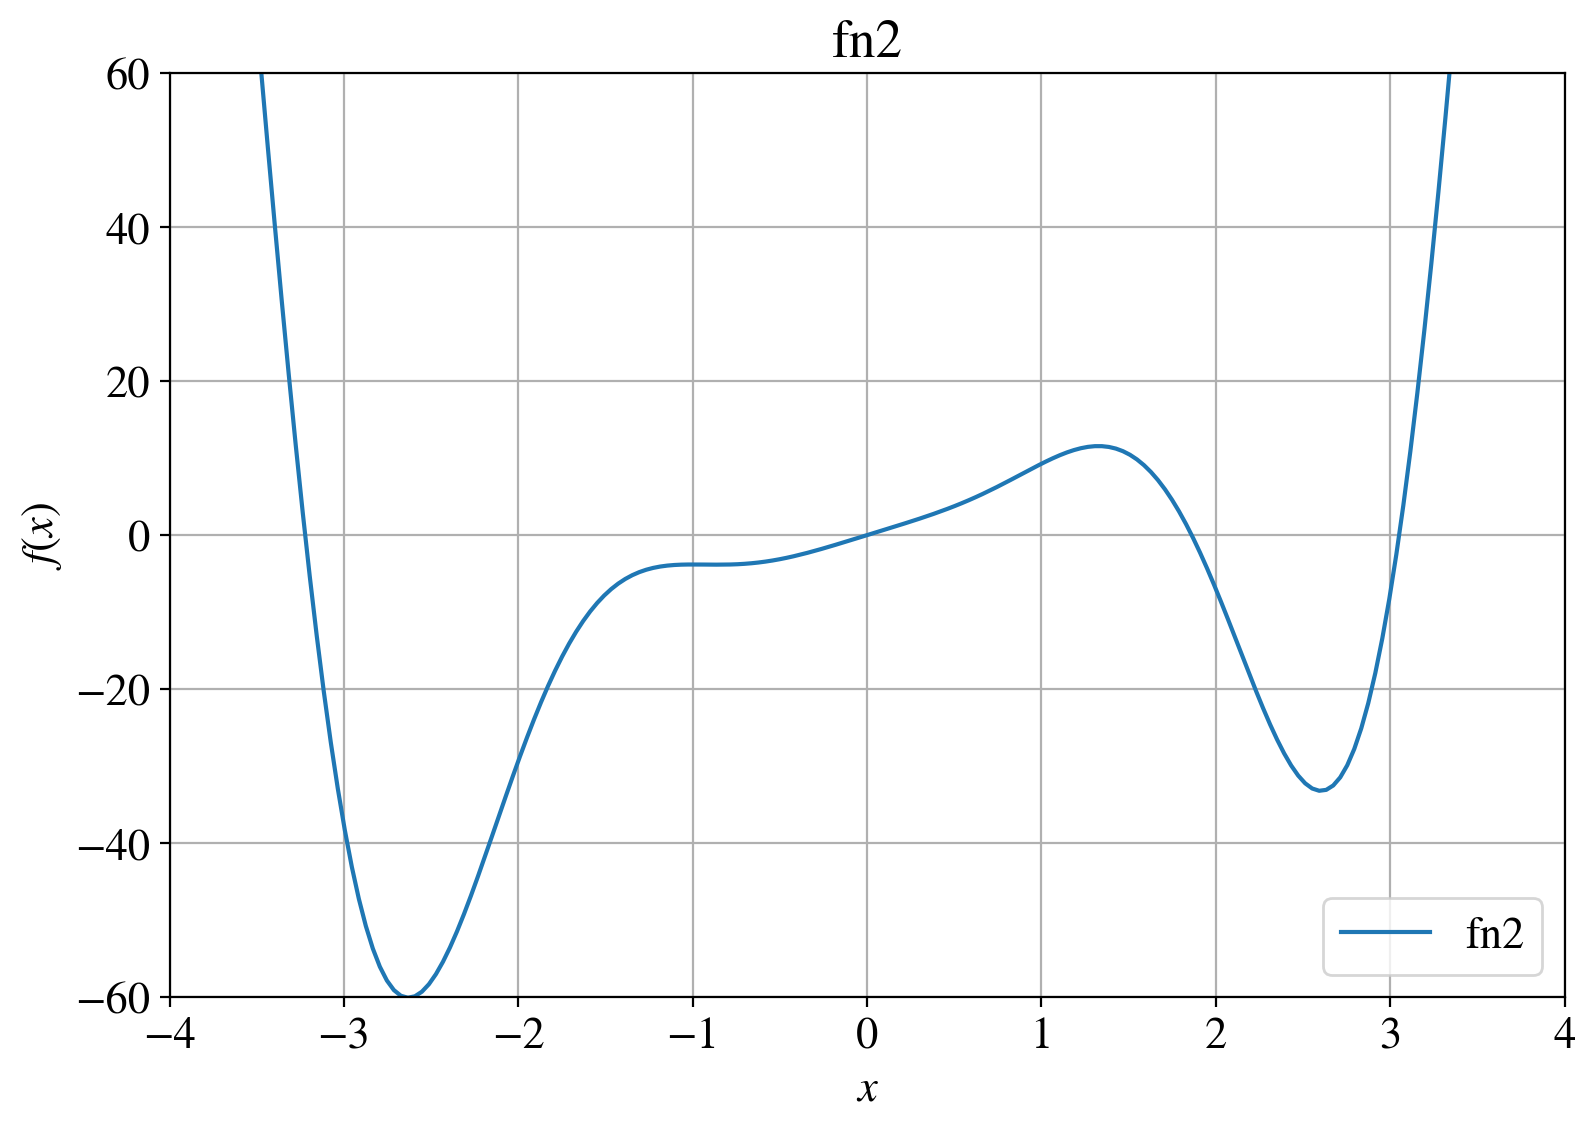

In [260]:
def fn2(x):
    return np.sin(2*x) * 3 * x**3 + np.cos(x) * x**1 + 6*x 
    
x2_min, x2_max = -4.0, 4.0

x2_series = np.linspace(-4, 4, 200)
y2_series = fn2(x2_series)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(x2_series, y2_series, label = 'fn2')

ax.set_title('fn2')
plt.xlabel( r"$x$")
plt.ylabel( r"$f(x)$")

ax.legend(loc='best')

ax.set_xlim(-4, 4)
ax.set_ylim(-60, 60)

ax.grid()




In [261]:
##====== 极大值
peaks_max, props_max = find_peaks(y2_series, prominence=0.05, distance=30)
##====== 极小值
peaks_min, props_min = find_peaks(-y2_series, prominence=0.05, distance=30)

x2_maxima = x2_series[peaks_max]
x2_minima = x2_series[peaks_min]

# ====== 组装“边界 + 极大 + 极小”作为切点 ======
cuts = np.unique( np.concatenate([ [x2_min, x2_max], x2_maxima, x2_minima ]) )
cuts.sort()
cuts

array([-4.        , -2.63316583,  1.34673367,  2.59296482,  4.        ])

In [262]:
def roots_by_critical_segments(fun, cuts, merge_tol=1e-6, eps_x=1e-12, eps_f=1e-12):
    """
    在“由边界 + 极大值 + 极小值”构成的切点 cuts 上，逐段 [cuts[i], cuts[i+1]]
    用端点符号判断是否存在根，若存在用二分法求根。
    - fun:     目标函数
    - cuts:    已排序的切点列表/数组（必须包含整体区间的左右边界）
    - merge_tol: 根的去重阈值（两个根距离小于该值就视为同一个）
    - eps_x, eps_f, maxit: 传给二分法的精度与迭代上限
    返回：按从小到大排序的根列表（list）
    """
    roots = []
    cuts = np.sort(np.array(cuts))

    def add_root(r):
        """
        把新得到的根 r 加入 roots。
        如果与已有某个根很接近（差小于 merge_tol），就做一次简单平均合并。
        这里用最简单的线性扫描，便于学生理解。
        """
        for i, rr in enumerate(roots):
            if abs(rr - r) <= merge_tol:
                roots[i] = 0.5*(rr + r)
                return
        roots.append(r)

    for a, b in zip(cuts[:-1], cuts[1:]):
        
        fa, fb = fun(a), fun(b)
        
        ##====== 端点即为根
        if fa == 0.0:
            add_root(a)
            continue
        if fb == 0.0:
            add_root(b)
            continue
            
        ##====== 仅当端点异号才在该段二分
        if fa * fb < 0.0:
            r = bisection(fun, a, b, eps_x=eps_x, eps_f=eps_f)
            add_root(r)

    return np.array(sorted(roots))


In [263]:
roots = roots_by_critical_segments(fn2, cuts, merge_tol=1e-6,
                                   eps_x=1e-12, eps_f=1e-12)
print(f"分段得到的根个数：{len(roots)}")
print("roots =", roots)

分段得到的根个数：4
roots = [-3.22225426e+00  1.82185000e-14  1.86166892e+00  3.05154304e+00]


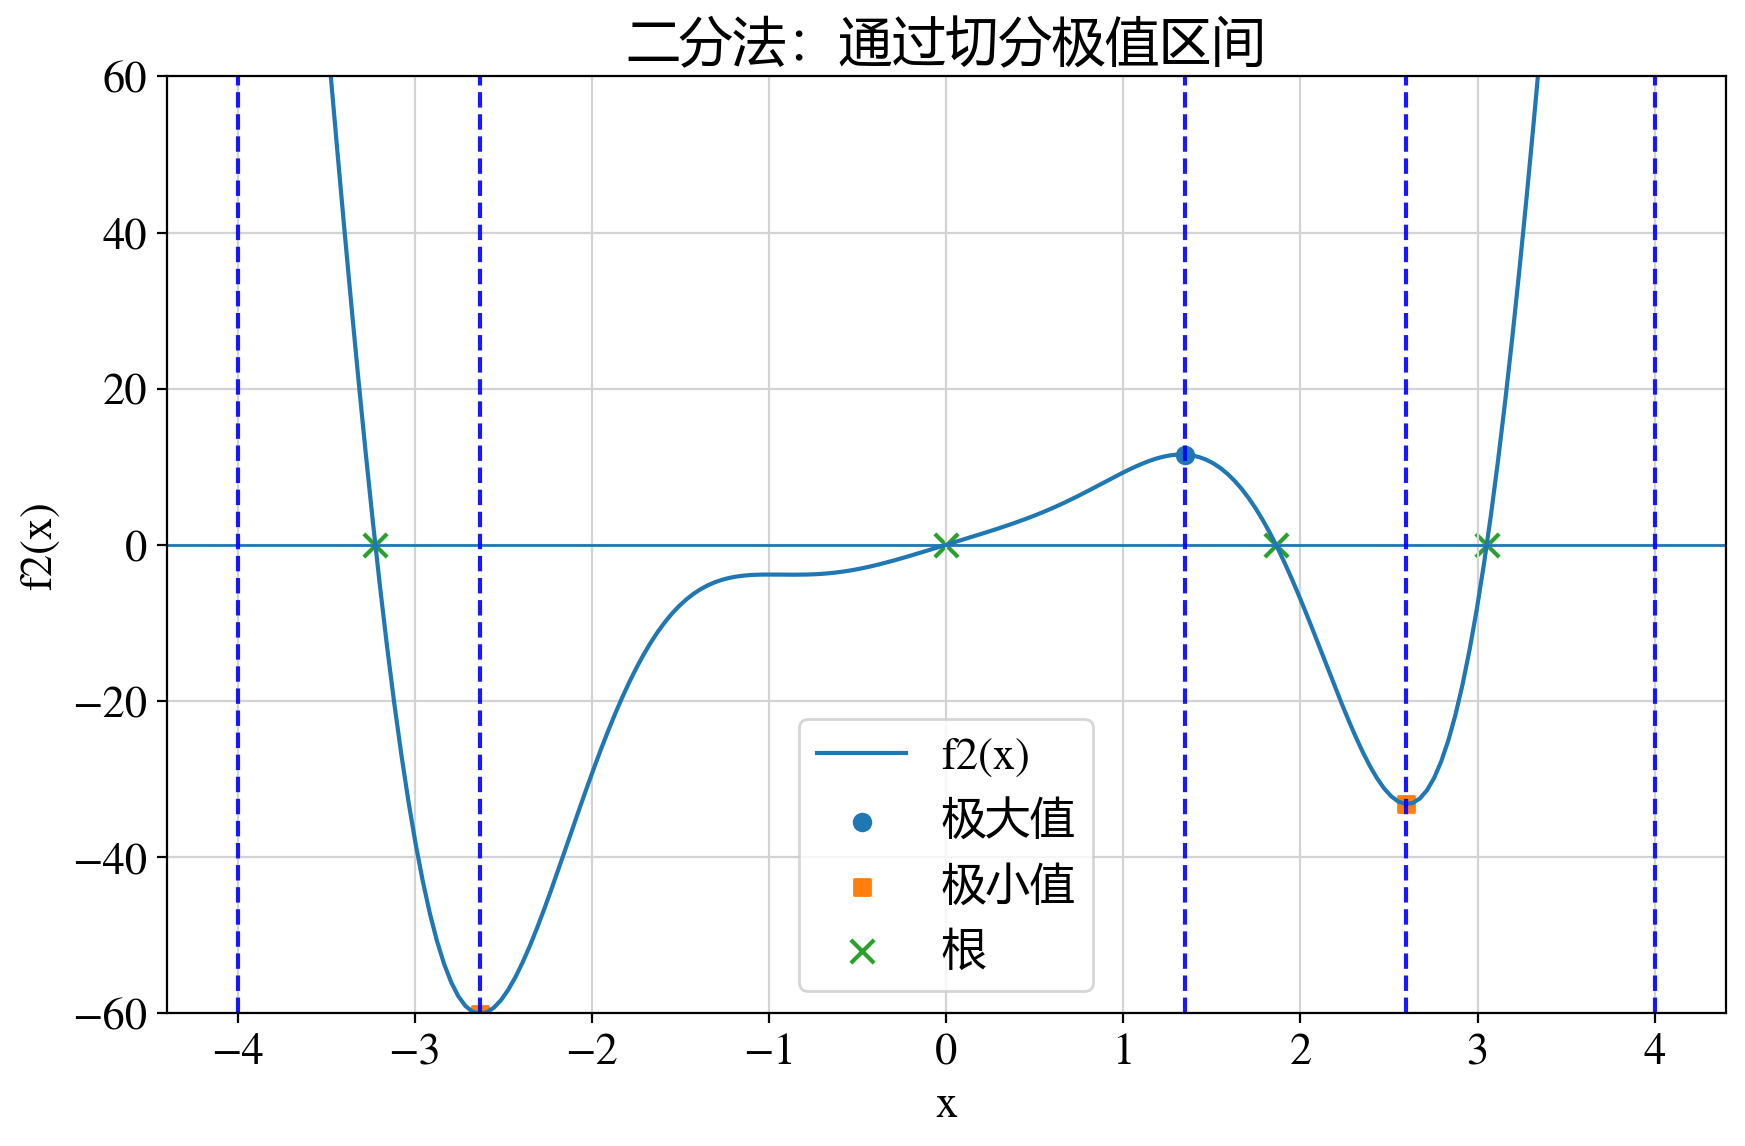

In [264]:
# ====== 可视化：曲线、极大/极小、切点、根 ======
plt.figure(figsize=(9, 6))
plt.plot(x2_series, y2_series, label="f2(x)")
plt.axhline(0.0, linewidth=1)

# 极大值/极小值
plt.scatter(x2_maxima, fn2(x2_maxima), marker="o", label="极大值")
plt.scatter(x2_minima, fn2(x2_minima), marker="s", label="极小值")

# 切点（边界 + 极值）
for cx in cuts:
    plt.axvline(cx, color="blue", linestyle="--", alpha=0.9)

# 根
plt.scatter(roots, fn2(roots), marker="x", s=70, label="根")

plt.title("二分法：通过切分极值区间")
plt.xlabel("x")
plt.ylabel("f2(x)")
plt.ylim(-60, 60)
plt.legend()
plt.grid(visible=True, which='major', color='lightgrey', linestyle='-')
plt.grid(visible=True, which='minor', color='lightgrey', linestyle=':')

plt.tight_layout()
plt.show()


# 截弦法（Secant Method）

In [266]:
# ===============================
# 1) 纯净版：截弦法（带历史 + 防护）
# ===============================
import math
import numpy as np
import matplotlib.pyplot as plt

def secant(func, x0, x1, eps_x=1e-10, eps_f=1e-12, maxit=100, case=1):
    """
    截弦法：用两个初值 x0, x1 迭代求 f(x)=0 的根。
    返回: root, history
    history: 列表，每步包含 {k, x, fx}
    """
    x_prev = float(x0)
    x_curr = float(x1)
    f_prev = func(x_prev)
    f_curr = func(x_curr)

    history = [{"k": 0, "x": x_prev, "fx": f_prev},
               {"k": 1, "x": x_curr, "fx": f_curr}]

    # 若初值已是根
    if abs(f_prev) <= eps_f:
        return x_prev, history
    if abs(f_curr) <= eps_f or abs(x_curr - x_prev) <= eps_x:
        return x_curr, history

    for k in range(2, maxit + 1):
        denom = (f_curr - f_prev)
        if denom == 0.0:  # 防止分母为0
            # 直接返回当前值，或抛错；这里返回，交给外部做兜底（如二分/布伦特）
            return x_curr, history

        # 截弦更新
        x_next = x_curr - f_curr * (x_curr - x_prev) / denom
        f_next = func(x_next)

        history.append({"k": k, "x": x_next, "fx": f_next})

        # 停机条件
        if abs(f_next) <= eps_f or abs(x_next - x_curr) <= eps_x:
            return x_next, history

        if case == 1:
            # 换位推进
            x_prev, f_prev = x_curr, f_curr
            x_curr, f_curr = x_next, f_next
        elif case == 2:
            # 只替换“同号端点”，保持异号括区不变
            if f_prev*f_next < 0:
                x_curr, f_curr = x_next, f_next
            else:
                x_prev, f_prev = x_next, f_next

    # 达到最大迭代
    return x_curr, history


In [267]:
# ===============================
# 3) 可视化：几何直观（割线与 x 轴交点）
# ===============================
def demo_secant_geometry(func, x0, x1, n_steps=5, x_view=None, title=None):
    """
    画出若干步截弦几何：点、割线、与 x 轴交点。
    """
    if x_view is None:
        
        x_view = (min(x0, x1) - 1.0, max(x0, x1) + 1.0)
    xs = np.linspace(x_view[0], x_view[1], 600)
    ys = np.array([func(x) for x in xs])

    # 运行若干步，收集点
    root, hist = secant(func, x0, x1, maxit=n_steps)
    pts = [(h["x"], h["fx"]) for h in hist]

    plt.figure(figsize=(9, 6))
    plt.axhline(0.0, color="k", linewidth=1)
    plt.plot(xs, ys, label="f(x)")

    # 逐步画割线
    for i in range(1, min(len(pts)-0, n_steps)+0):
        x_prev, f_prev = pts[i-1]
        x_curr, f_curr = pts[i]
        # 画两个点
        plt.scatter([x_prev, x_curr], [f_prev, f_curr], s=50, zorder=3)
        # 画割线
        if (x_curr - x_prev) != 0.0:
            slope = (f_curr - f_prev) / (x_curr - x_prev)
            # 画一小段割线（这里简单用两端延长一点）
            xL = min(x_prev, x_curr) - 0.5*(x_view[1]-x_view[0])*0.05
            xR = max(x_prev, x_curr) + 0.5*(x_view[1]-x_view[0])*0.05
            yL = f_prev + slope*(xL - x_prev)
            yR = f_prev + slope*(xR - x_prev)
            plt.plot([xL, xR], [yL, yR], linestyle="--", alpha=0.8)

        plt.vlines( x_curr, ymin=min(0, f_curr ), ymax = max(0, f_curr ), 
                    color = 'lightgrey', linestyle='dashed' )
        plt.hlines( f_curr, xmin=max( min(0, x_curr), x0-0.1 ), xmax = max(0, x_curr, x0-0.1 ), 
                    color = 'lightgrey', linestyle='dashed' )

    # 标注最终近似根
    plt.scatter([root], [func(root)], marker="x", s=100, label="approx. root")
    

    if title:
        plt.title(title)
    else:
        plt.title("Secant method geometry")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$f(x)$")
    plt.xlim(x0-0.1, x1+0.1)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [268]:
# 示例用法
def fn1(x):
    return x**3 + 5*x**2 + 6*x 

# 需要确保区间 [a,b] 上 f(a)*f(b) < 0
x_min, x_max = -4.0, 1.0

root = bisection(fn1, x_min, x_max, eps_x=1e-6, eps_f=1e-10, maxit=1000)
print("Root≈", root)


Root≈ 5.960464477539063e-08


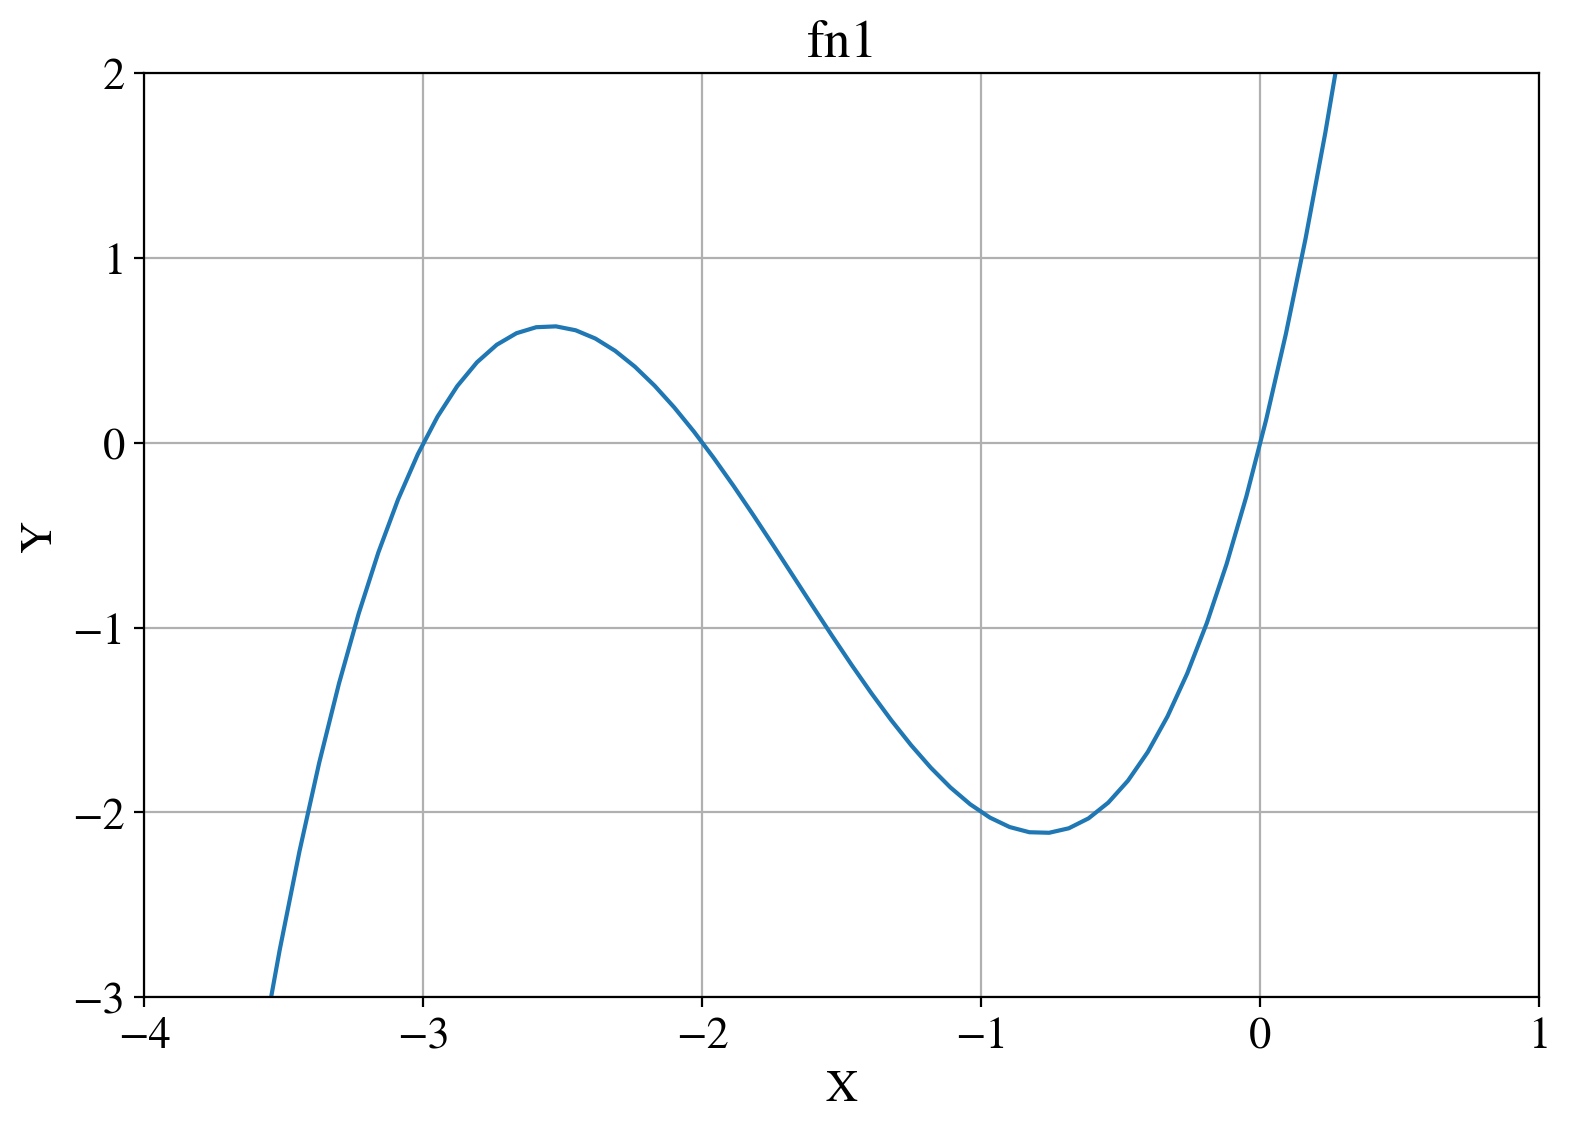

In [269]:
x_series = np.linspace(-5, 2, 100)
y_series = fn1(x_series)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(x_series, y_series)

ax.set_title('fn1')
ax.set_xlabel('X')
ax.set_ylabel('Y')
#ax.legend(loc='best') # 设置图例位置

ax.set_xlim(x_min, x_max)
ax.set_ylim(-3, 2)

ax.grid()


### 课堂练习：用截弦法求解`fn1`

[练习] 近似根 = -0.004410645447, f(root) = -2.637e-02, 迭代步数 = 6


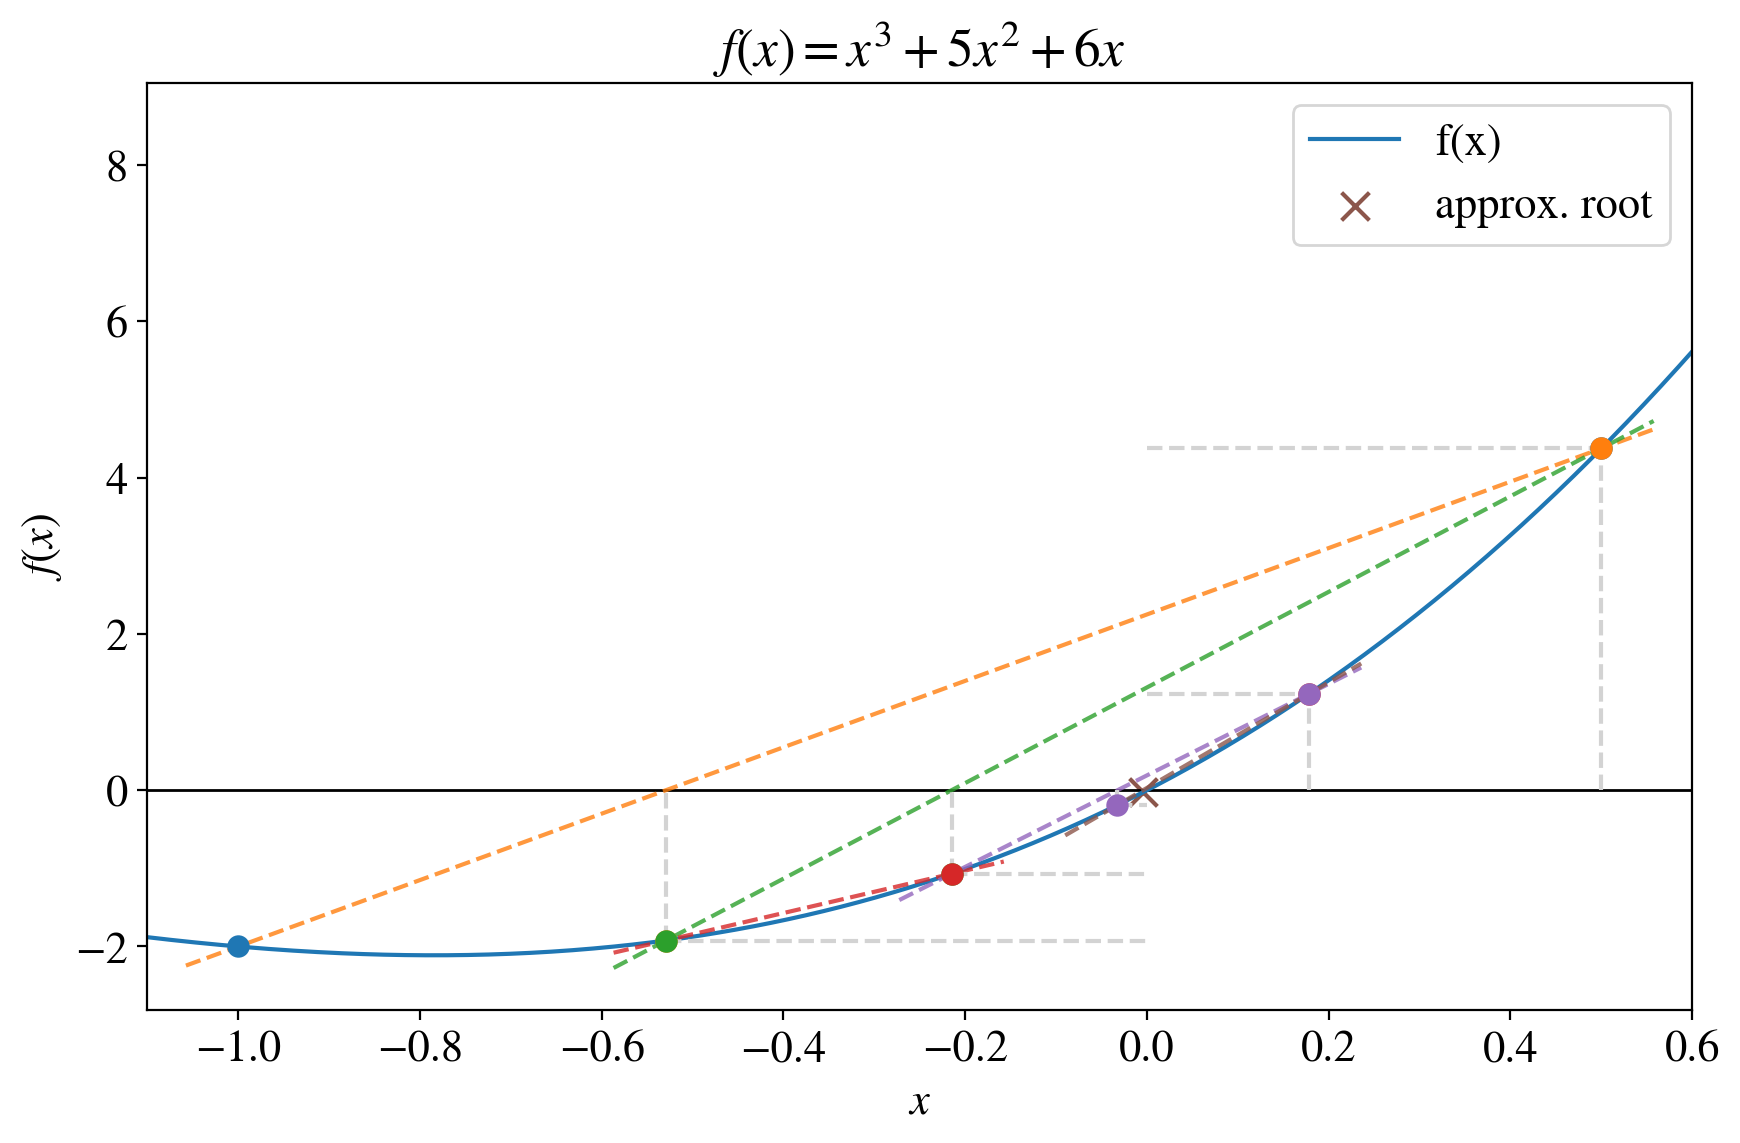

In [271]:
def fn1(x):
    return x**3 + 5*x**2 + 6*x

x0, x1 = -1.0, 0.5  
root1, hist1 = secant(fn1, x0, x1, maxit=6, case=1)

print(f"[练习] 近似根 = {root1:.12f}, f(root) = {fn1(root1):.3e}, 迭代步数 = {len(hist1)-1}")

demo_secant_geometry(fn1, x0, x1, 
                     n_steps=6, 
                     x_view=(-1.5, 0.8), 
                     title=r"$f(x)=x^3 + 5x^2 + 6x$")

根x=-2的近似结果：-1.500000000000，f(root)=-1.125e+00，迭代步数=8


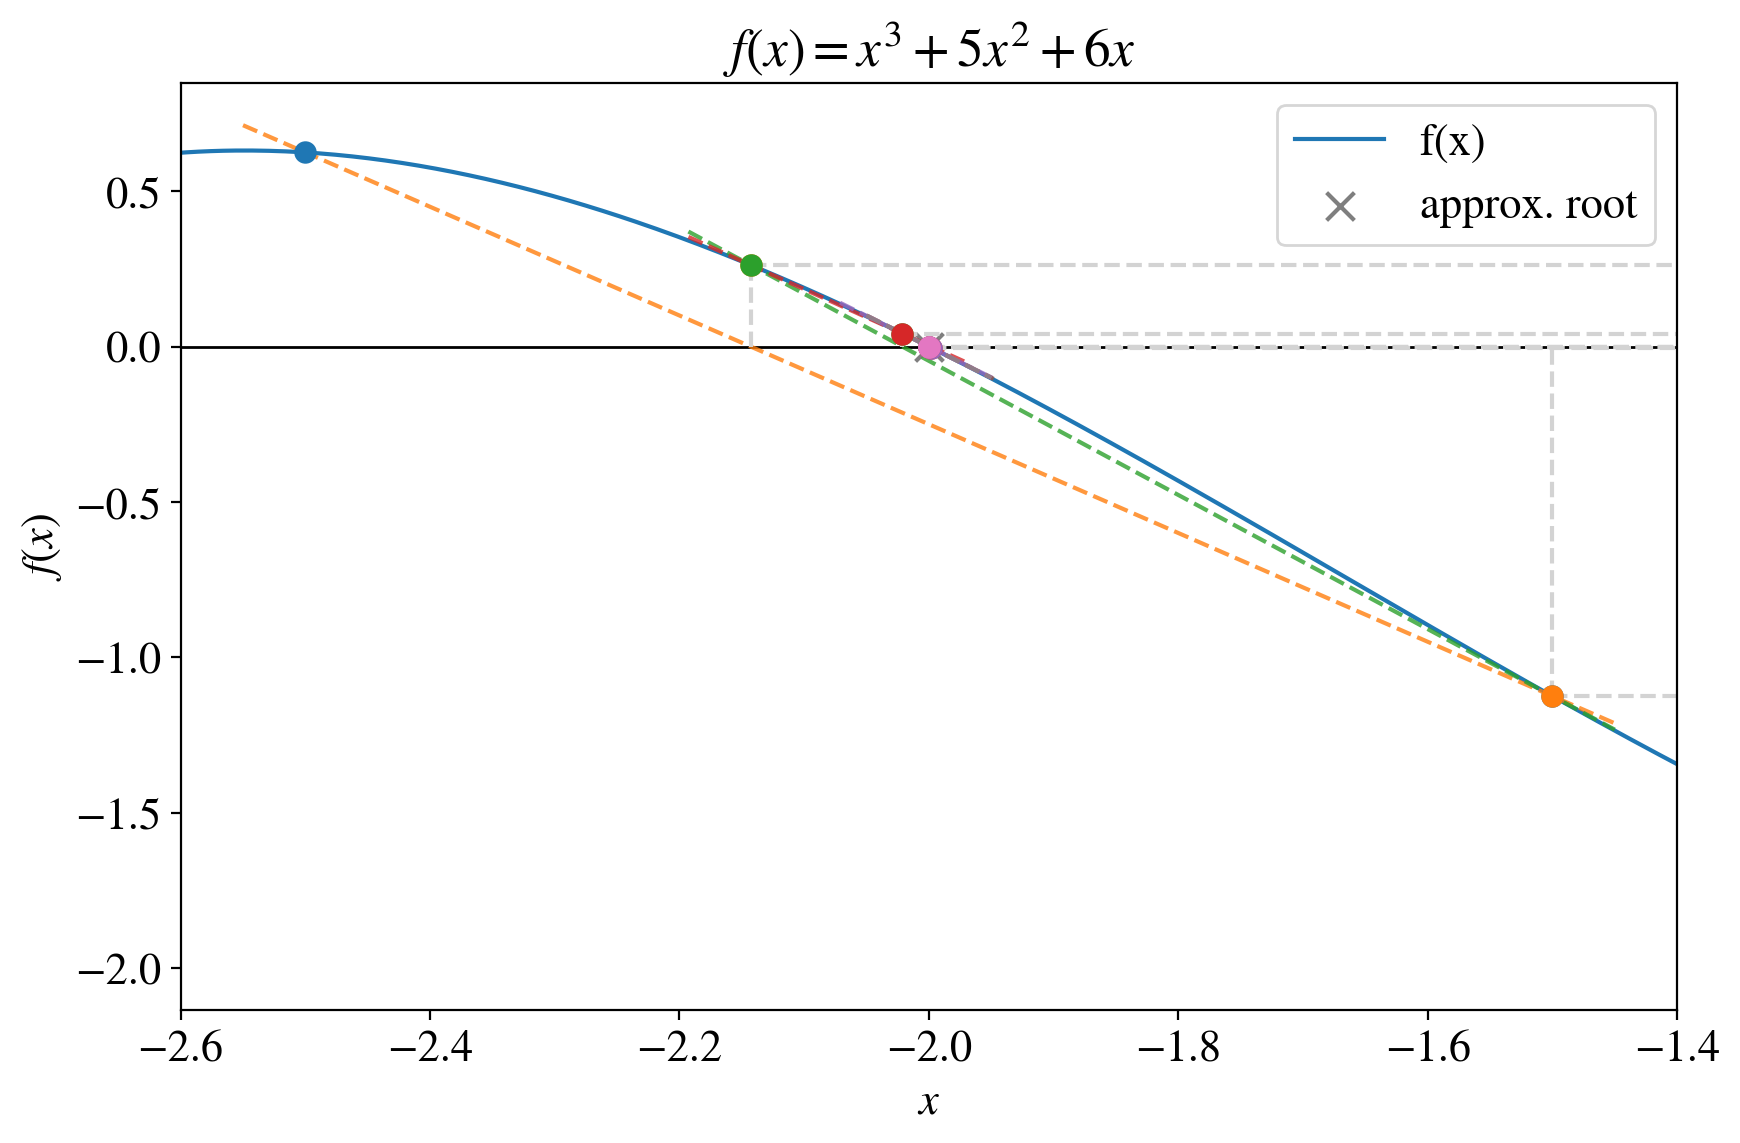

In [272]:
x0_2, x1_2 = -2.5, -1.5  
root2, hist2 = secant(fn1, x0_2, x1_2, maxit=8, case=2)  # case=2保持异号括区

print(f"根x=-2的近似结果：{root2:.12f}，f(root)={fn1(root2):.3e}，迭代步数={len(hist2)-1}")

demo_secant_geometry(fn1, x0_2, x1_2, 
                     n_steps=8, 
                     x_view=(-3.0, -1.0), 
                     title=r"$f(x)=x^3 + 5x^2 + 6x$")

根x=-3的近似结果：-3.200000000000，f(root)=-7.680e-01，迭代步数=8


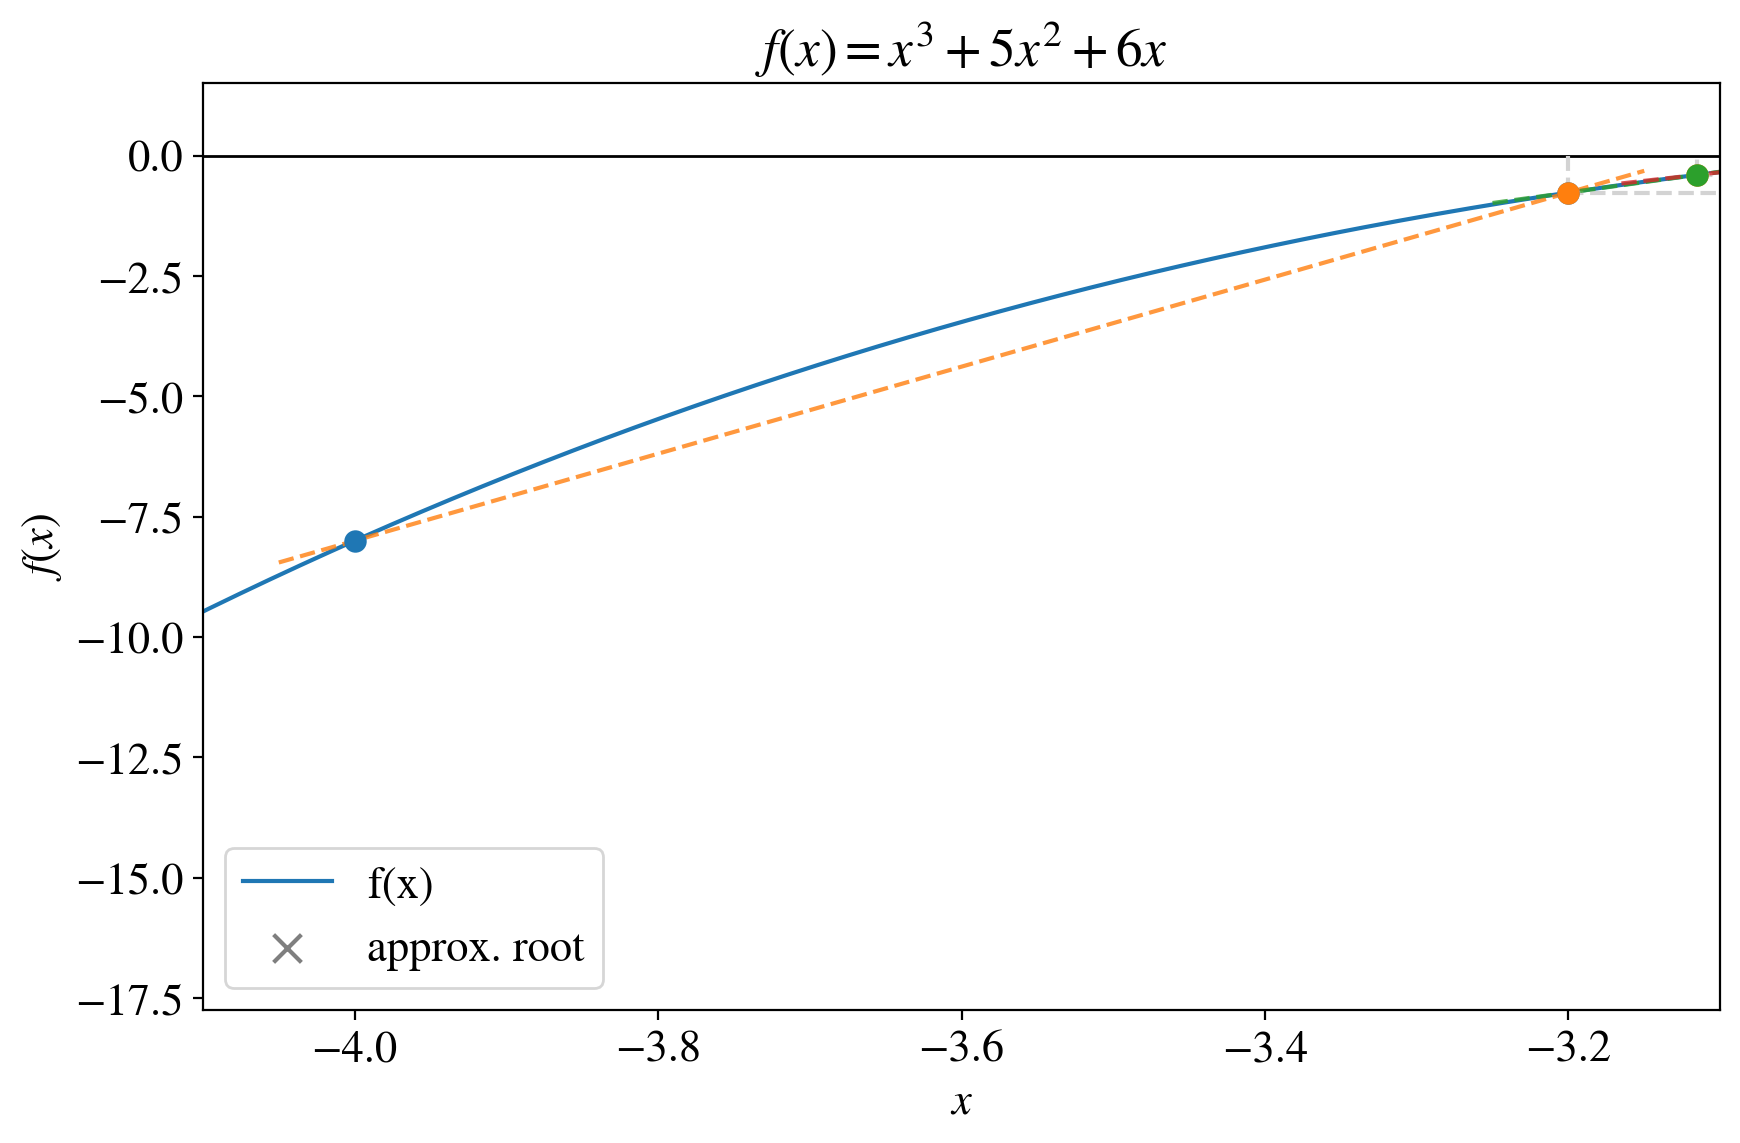

In [273]:
x0_3, x1_3 = -4.0, -3.2  
root3, hist3 = secant(fn1, x0_3, x1_3, maxit=8, case=2)

print(f"根x=-3的近似结果：{root3:.12f}，f(root)={fn1(root3):.3e}，迭代步数={len(hist3)-1}")

demo_secant_geometry(fn1, x0_3, x1_3, 
                     n_steps=8, 
                     x_view=(-4.5, -2.5), 
                     title=r"$f(x)=x^3 + 5x^2 + 6x$")

# 不动点迭代法（Fixed-Point Iteration）

In [275]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ---------- 1) 基础不动点迭代 ----------
def fixed_point(g_func, x0, tol_x=1e-10, tol_g=1e-12, maxit=200, track_f=None):
    """
    固定点迭代 x_{k+1} = g(x_k)
    参数:
      g: 迭代函数
      x0: 初值
      tol_x: 步长容差 |x_{k+1}-x_k|
      tol_g: 固定点残差容差 |g(x_k)-x_k|
      maxit: 最大迭代次数
      track_f: 可选 f 用于报告 |f(x)| 作为参考（不参与停止）
    返回:
      x, history
      history: 列表, 每项 dict(k, x, gx, step, fval)
    """
    x = float(x0)
    gx = g_func(x)
    history = [{"k": 0, "x": x, "gx": gx, "step": np.nan,
                "fval": (None if track_f is None else track_f(x))}]
    
    for k in range(1, maxit+1):
        step = gx - x
        x_new = gx
        gx_new = g_func(x_new)
        history.append({"k": k, "x": x_new, "gx": gx_new, "step": step,
                        "fval": (None if track_f is None else track_f(x_new))})
        
        # 停止
        if abs(step) <= tol_x or abs(gx_new - x_new) <= tol_g:
            return x_new, history
            
        # 推进
        x, gx = x_new, gx_new
        # 防爆
        if not np.isfinite(x) or abs(x) > 1e16:
            return x, history
            
    return x, history

# ---------- 2) 蛛网图 ----------
def cobweb_plot(g, x0, n=20, xlim=None, ylim=None, title=None):
    """
    画 y=g(x) 与 y=x 的蛛网图，从 x0 开始迭代 n 步。
    """
    if xlim is None:
        xlim = (x0 - 2, x0 + 2)
    xs = np.linspace(xlim[0], xlim[1], 800)
    ys = np.array([g(x) for x in xs])

    plt.figure(figsize=(7.5,5.2))
    plt.plot(xs, ys, label="y = g(x)")
    plt.plot(xs, xs, linestyle="--", label="y = x")
    # 蛛网步
    x = x0
    for k in range(n):
        gx = g(x)
        # vertical: (x, 0)->(x, g(x)) 其实画到曲线上即可
        plt.plot([x, x], [x, gx], alpha=0.8)       # 竖到 y=g(x)，同时也到 y=x？更严格应竖到 (x, g(x))
        # horizontal: (x, g(x))->(g(x), g(x)) 到 y=x 线
        plt.plot([x, gx], [gx, gx], alpha=0.8)
        x = gx
    plt.scatter([x0], [g(x0)], s=40, label="start")
    plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("x"); plt.ylabel("y")
    if title: plt.title(title)
    plt.legend(); plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout(); plt.show()


课堂练习
$$
 x^3 - x - 2 = 0
$$

[变换1] 不动点迭代：root ≈ 1.521379706804, 迭代步数 = 13


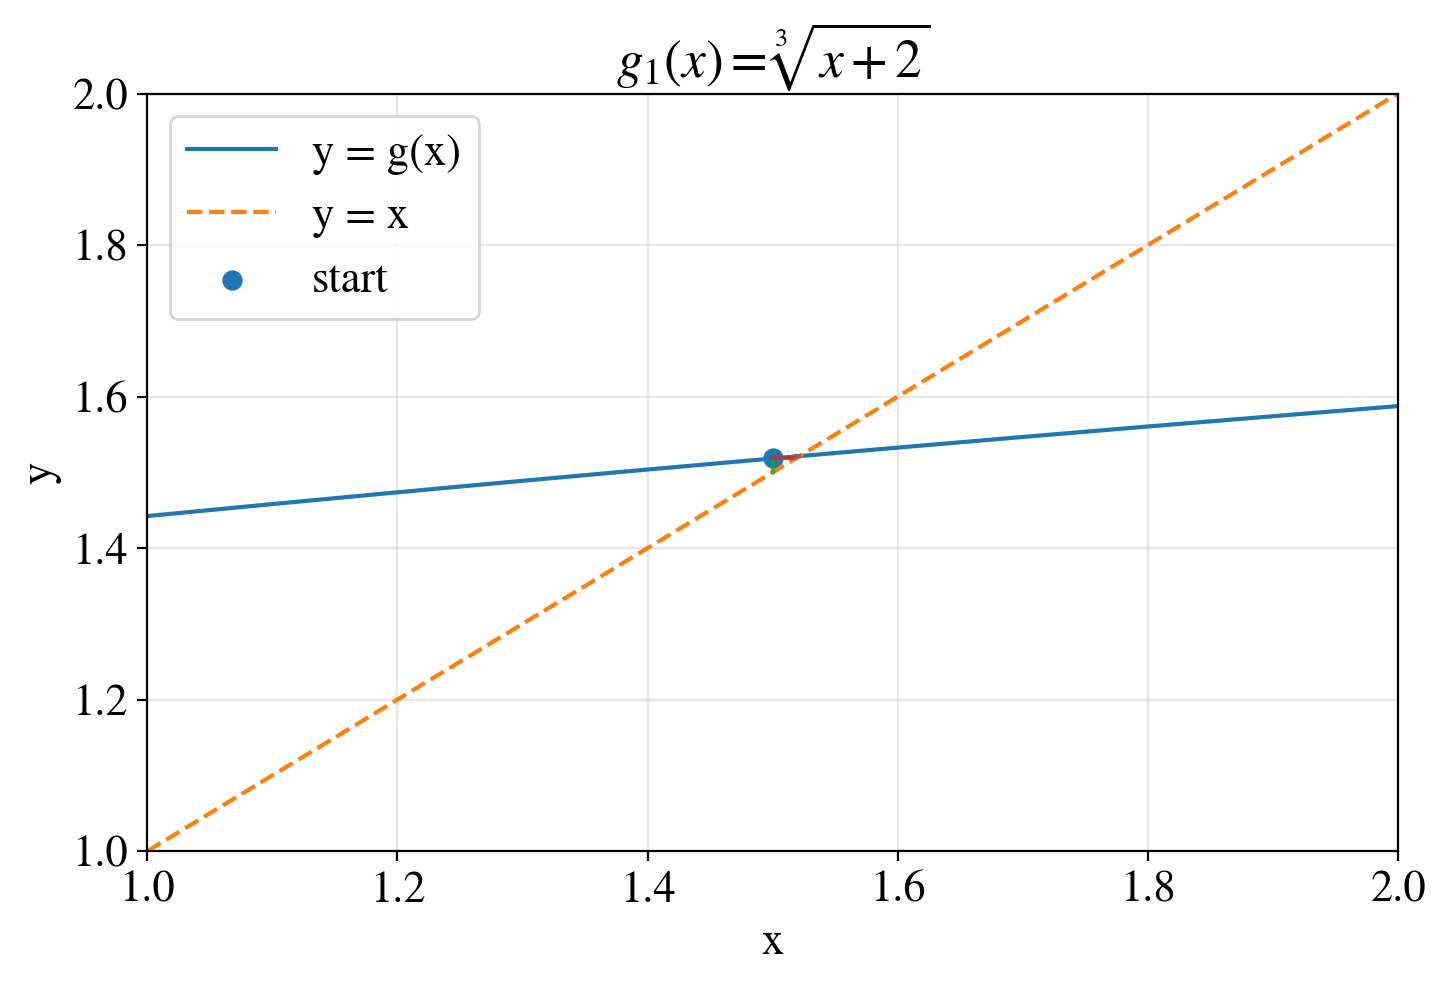

[变换2] 不动点迭代：root ≈ -841079144116905333227520.000000000000, 迭代步数 = 7


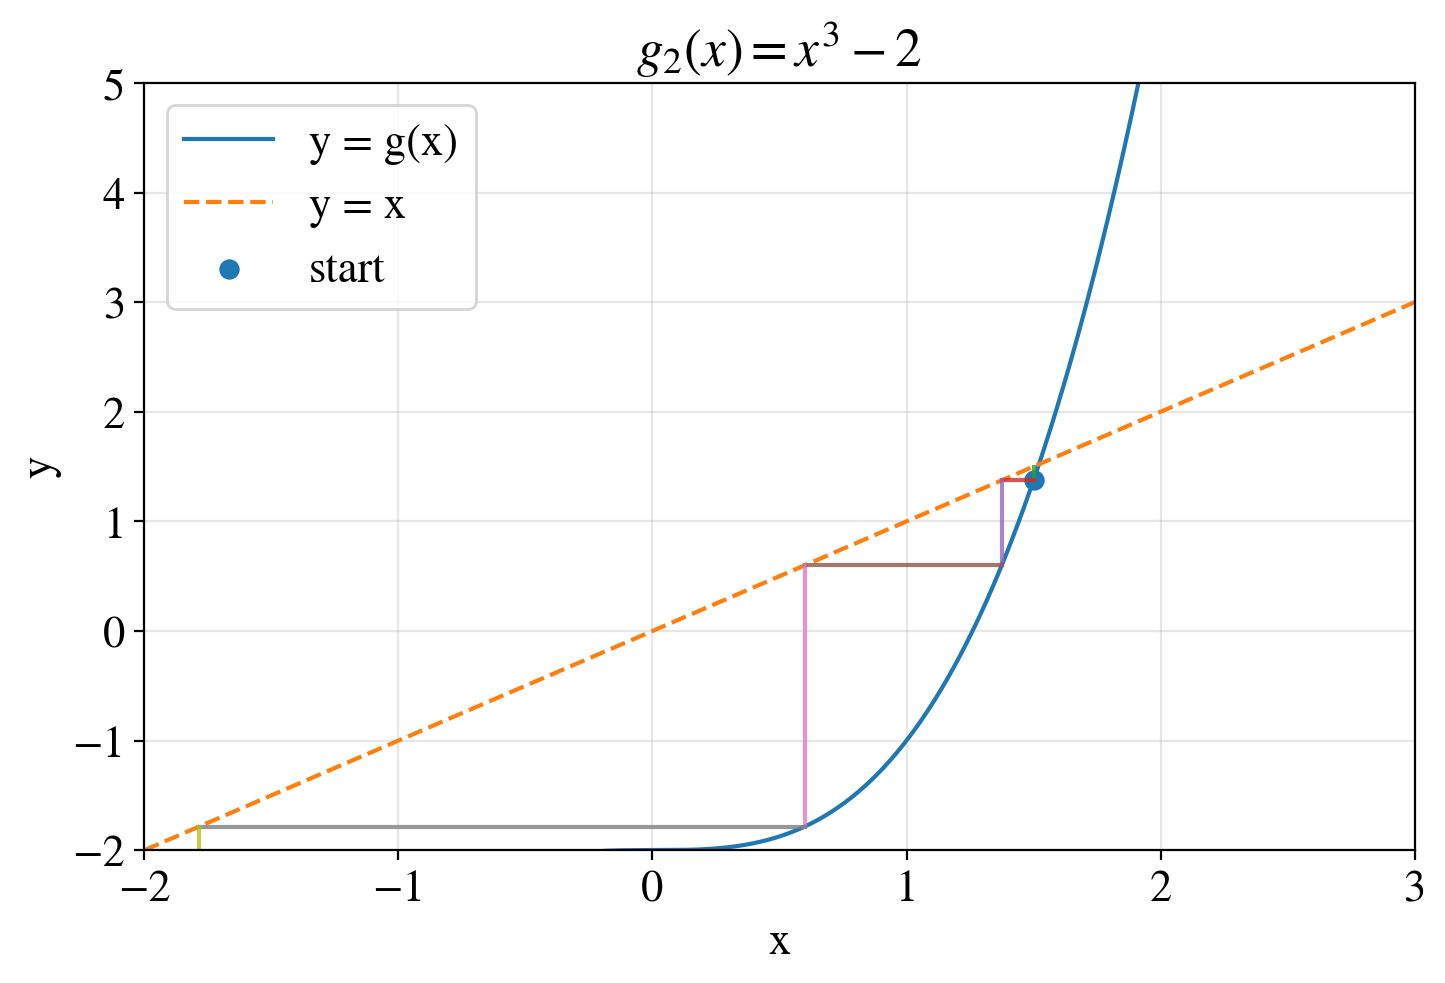

In [277]:
# 变换1：g1(x) = ∛(x + 2)
def g1_fn(x):
    return np.cbrt(x + 2)  # 三次根等价于 (x+2)**(1/3)

x0 = 1.5  # 初值（根在(1,2)之间，选1.5合理）
root1, hist1 = fixed_point(g1_fn, x0, tol_x=1e-12, tol_g=1e-12, maxit=100)
xs1 = [h["x"] for h in hist1]

print(f"[变换1] 不动点迭代：root ≈ {root1:.12f}, 迭代步数 = {len(xs1)-1}")

# 蛛网图可视化
cobweb_plot(g1_fn, x0, n=10, xlim=(1, 2), ylim=(1, 2), title=r"$g_1(x) = \sqrt[3]{x + 2}$")

# 变换2：g2(x) = x³ - 2（对比收敛性）
def g2_fn(x):
    return x ** 3 - 2

root2, hist2 = fixed_point(g2_fn, x0, tol_x=1e-12, tol_g=1e-12, maxit=100)
xs2 = [h["x"] for h in hist2]

print(f"[变换2] 不动点迭代：root ≈ {root2:.12f}, 迭代步数 = {len(xs2)-1}")

# 蛛网图可视化
cobweb_plot(g2_fn, x0, n=5, xlim=(-2, 3), ylim=(-2, 5), title=r"$g_2(x) = x^3 - 2$")

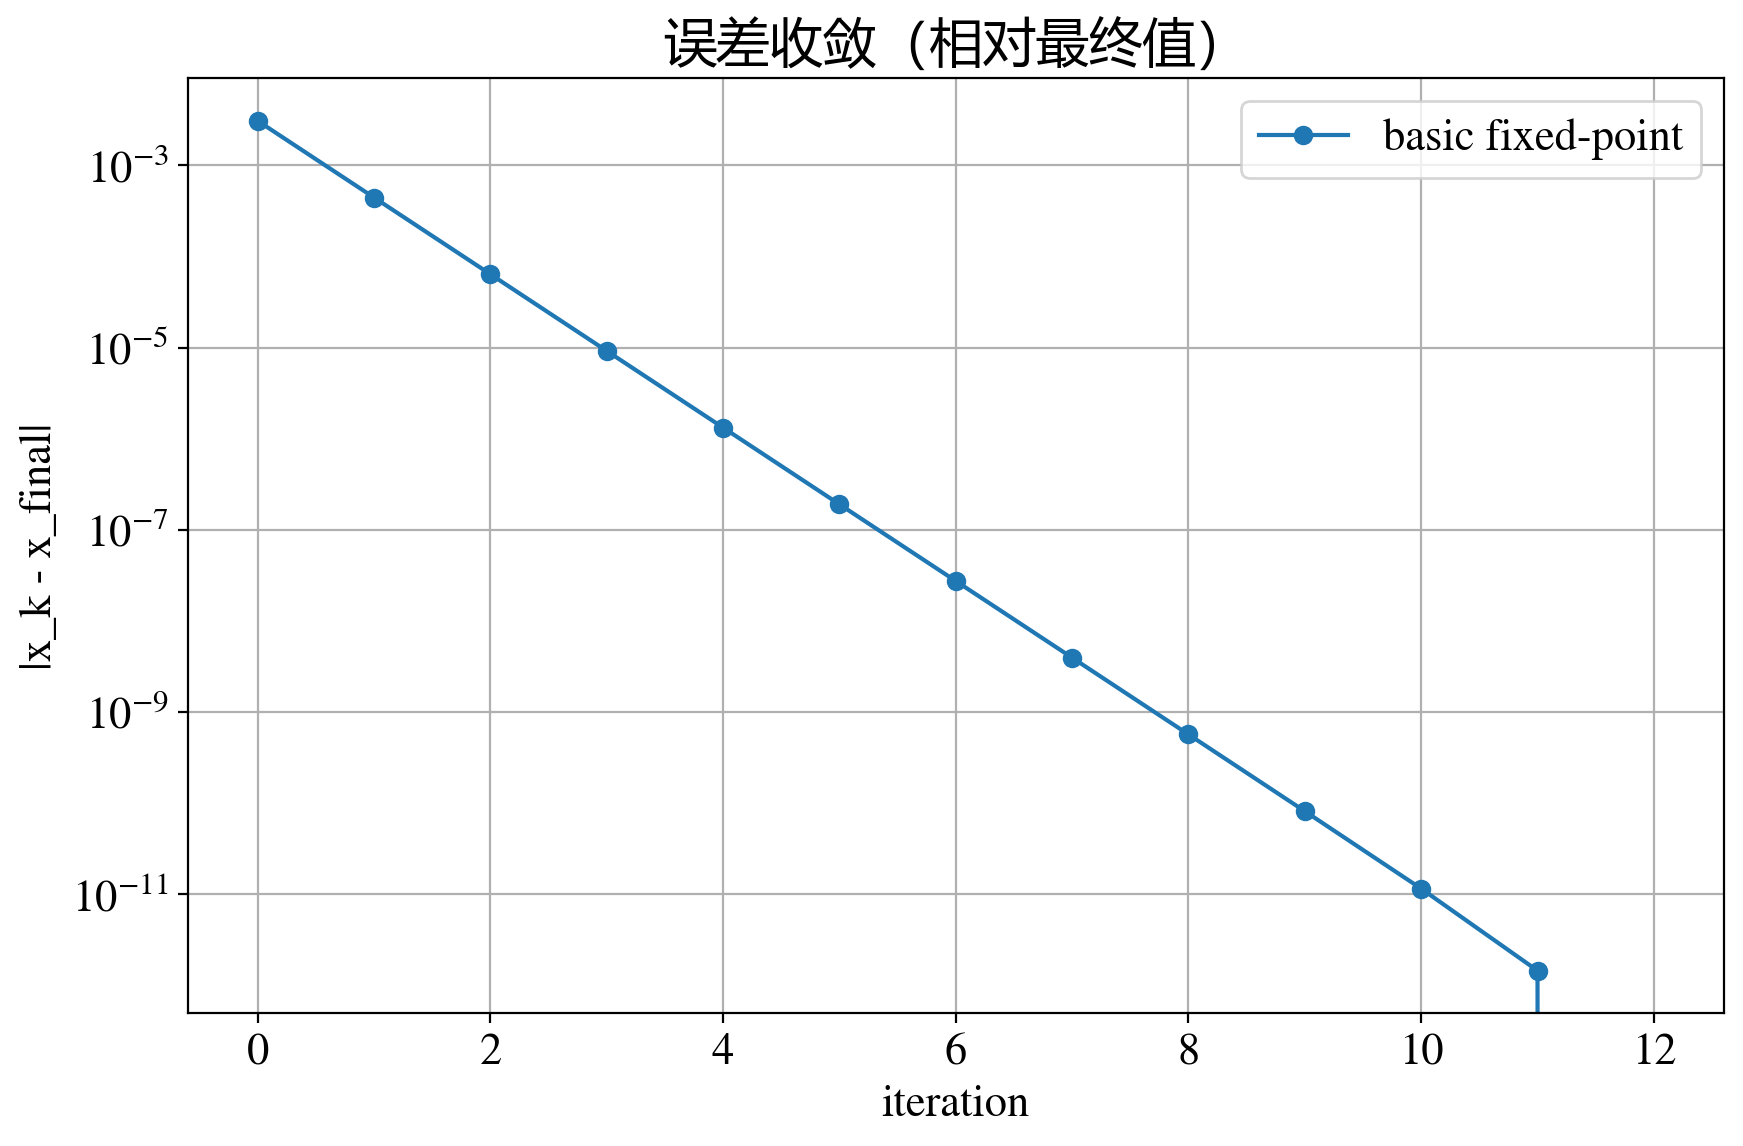

In [278]:
# 收敛曲线
errA = np.abs(np.array(xs1[1:]) - xs1[-1])

plt.figure(figsize=(9, 6))
plt.semilogy(errA, marker='o', label='basic fixed-point')
plt.title("误差收敛（相对最终值）")
plt.xlabel("iteration")
plt.ylabel("|x_k - x_final|")

plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()


## 课后作业

### 1. 用二分法
1. 在区间 $[0,1]$ 上求方程 $x^2 + x - 1 = 0$ 的近似根，要求误差不超过 $10^{-5}$。
2. 计算非线性方程 $x^3 - 2x^2 - x + 2 = 0$ 在区间 $[0.4,\,1.5]$ 上的根。



作业1 - 方程 x² + x - 1 = 0 在 [0,1] 上的根: 0.61803055
验证: f(0.61803055) = -7.69e-06


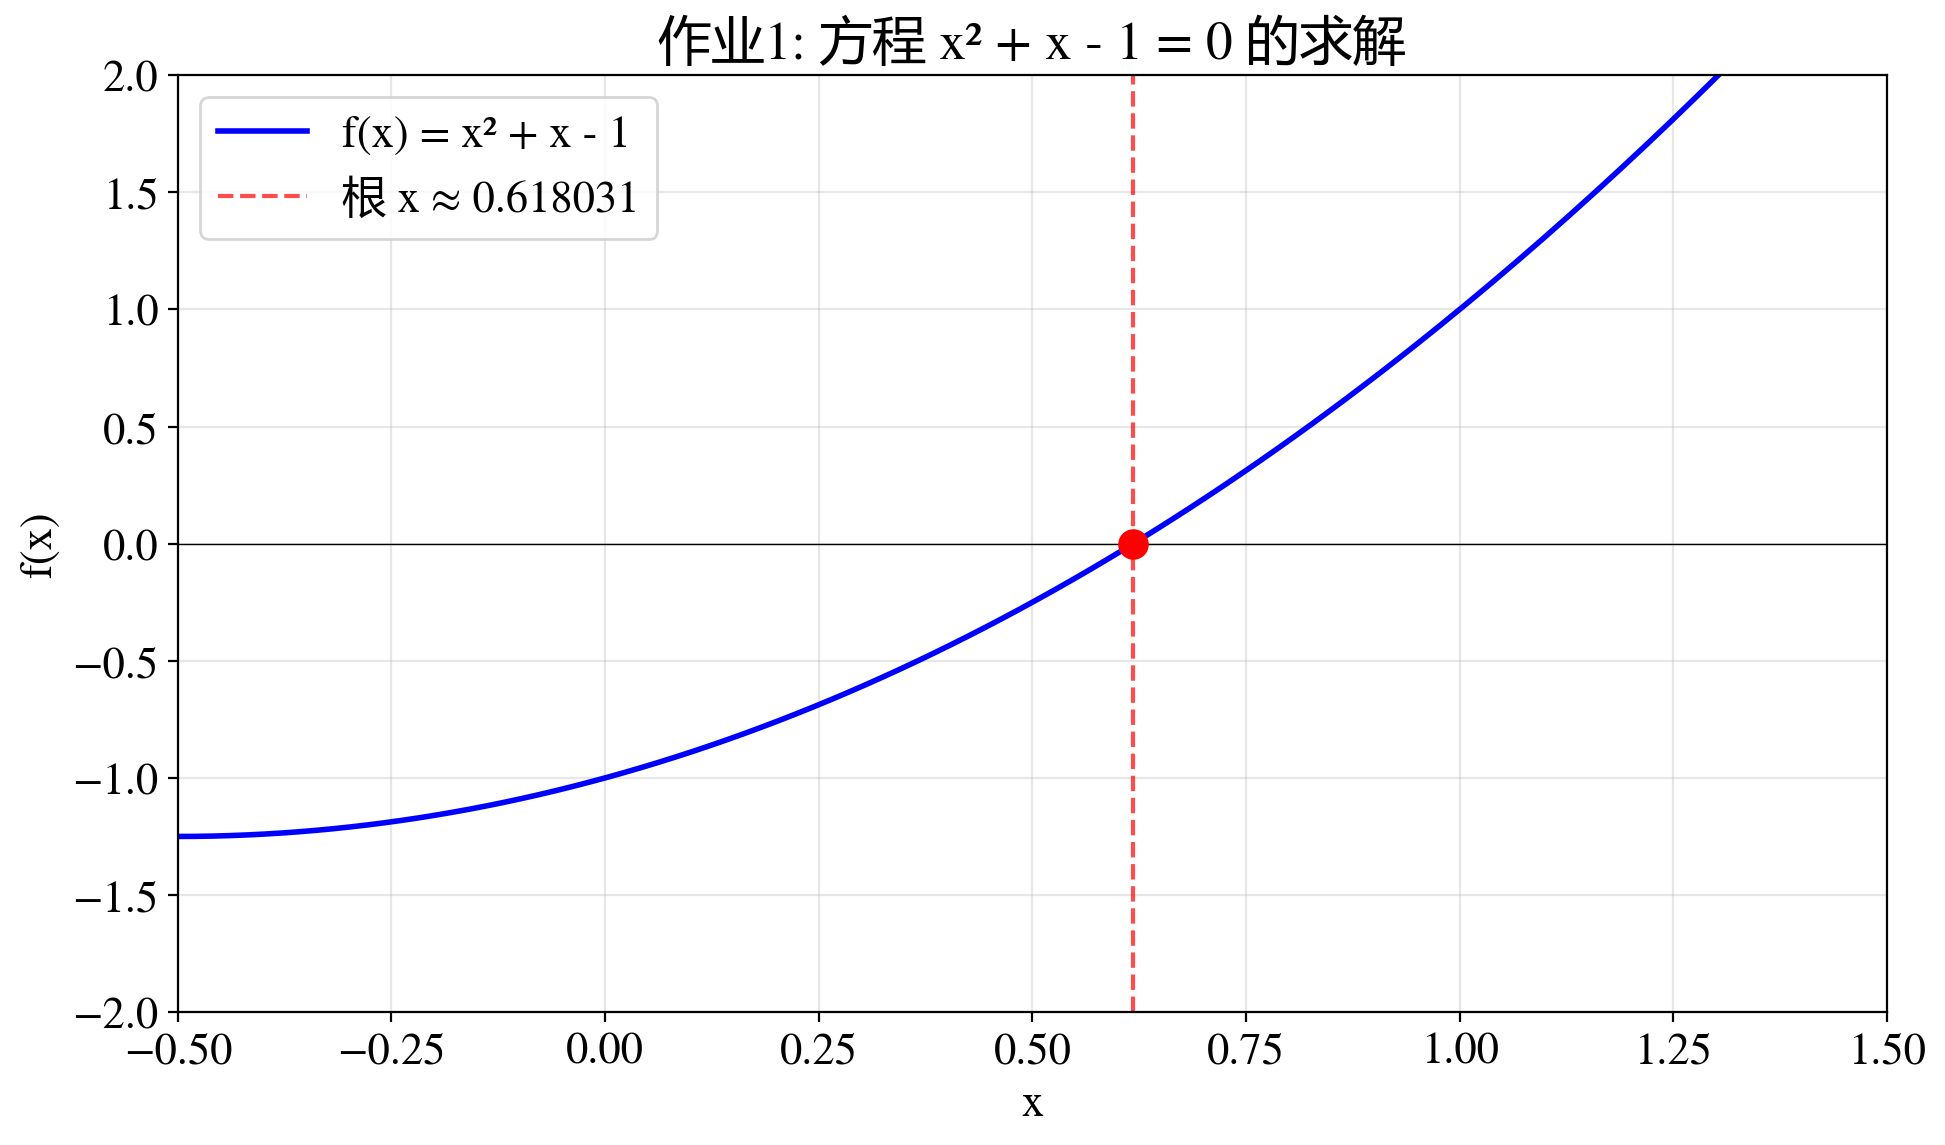

In [332]:
# 定义函数
def f1(x):
    return x**2 + x - 1

# 设置区间
x_min, x_max = 0.0, 1.0

# 使用二分法求根
root1 = bisection(f1, x_min, x_max, eps_x=1e-5, eps_f=1e-10)
print(f"作业1 - 方程 x² + x - 1 = 0 在 [0,1] 上的根: {root1:.8f}")
print(f"验证: f({root1:.8f}) = {f1(root1):.2e}")

# 可视化
x_series = np.linspace(-0.5, 1.5, 200)
y_series = f1(x_series)

plt.figure(figsize=(10, 6))
plt.plot(x_series, y_series, 'b-', linewidth=2, label='f(x) = x² + x - 1')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(root1, color='red', linestyle='--', alpha=0.7, label=f'根 x ≈ {root1:.6f}')
plt.scatter([root1], [f1(root1)], color='red', s=100, zorder=5)

plt.xlim(-0.5, 1.5)
plt.ylim(-2, 2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('作业1: 方程 x² + x - 1 = 0 的求解')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

作业2 - 简单二分法求得的根: 0.99999733
验证: f(0.99999733) = 5.34e-06
切点: [0.4        1.5        1.54682274]
作业2 - 分段求根法得到的根: [0.99999733]


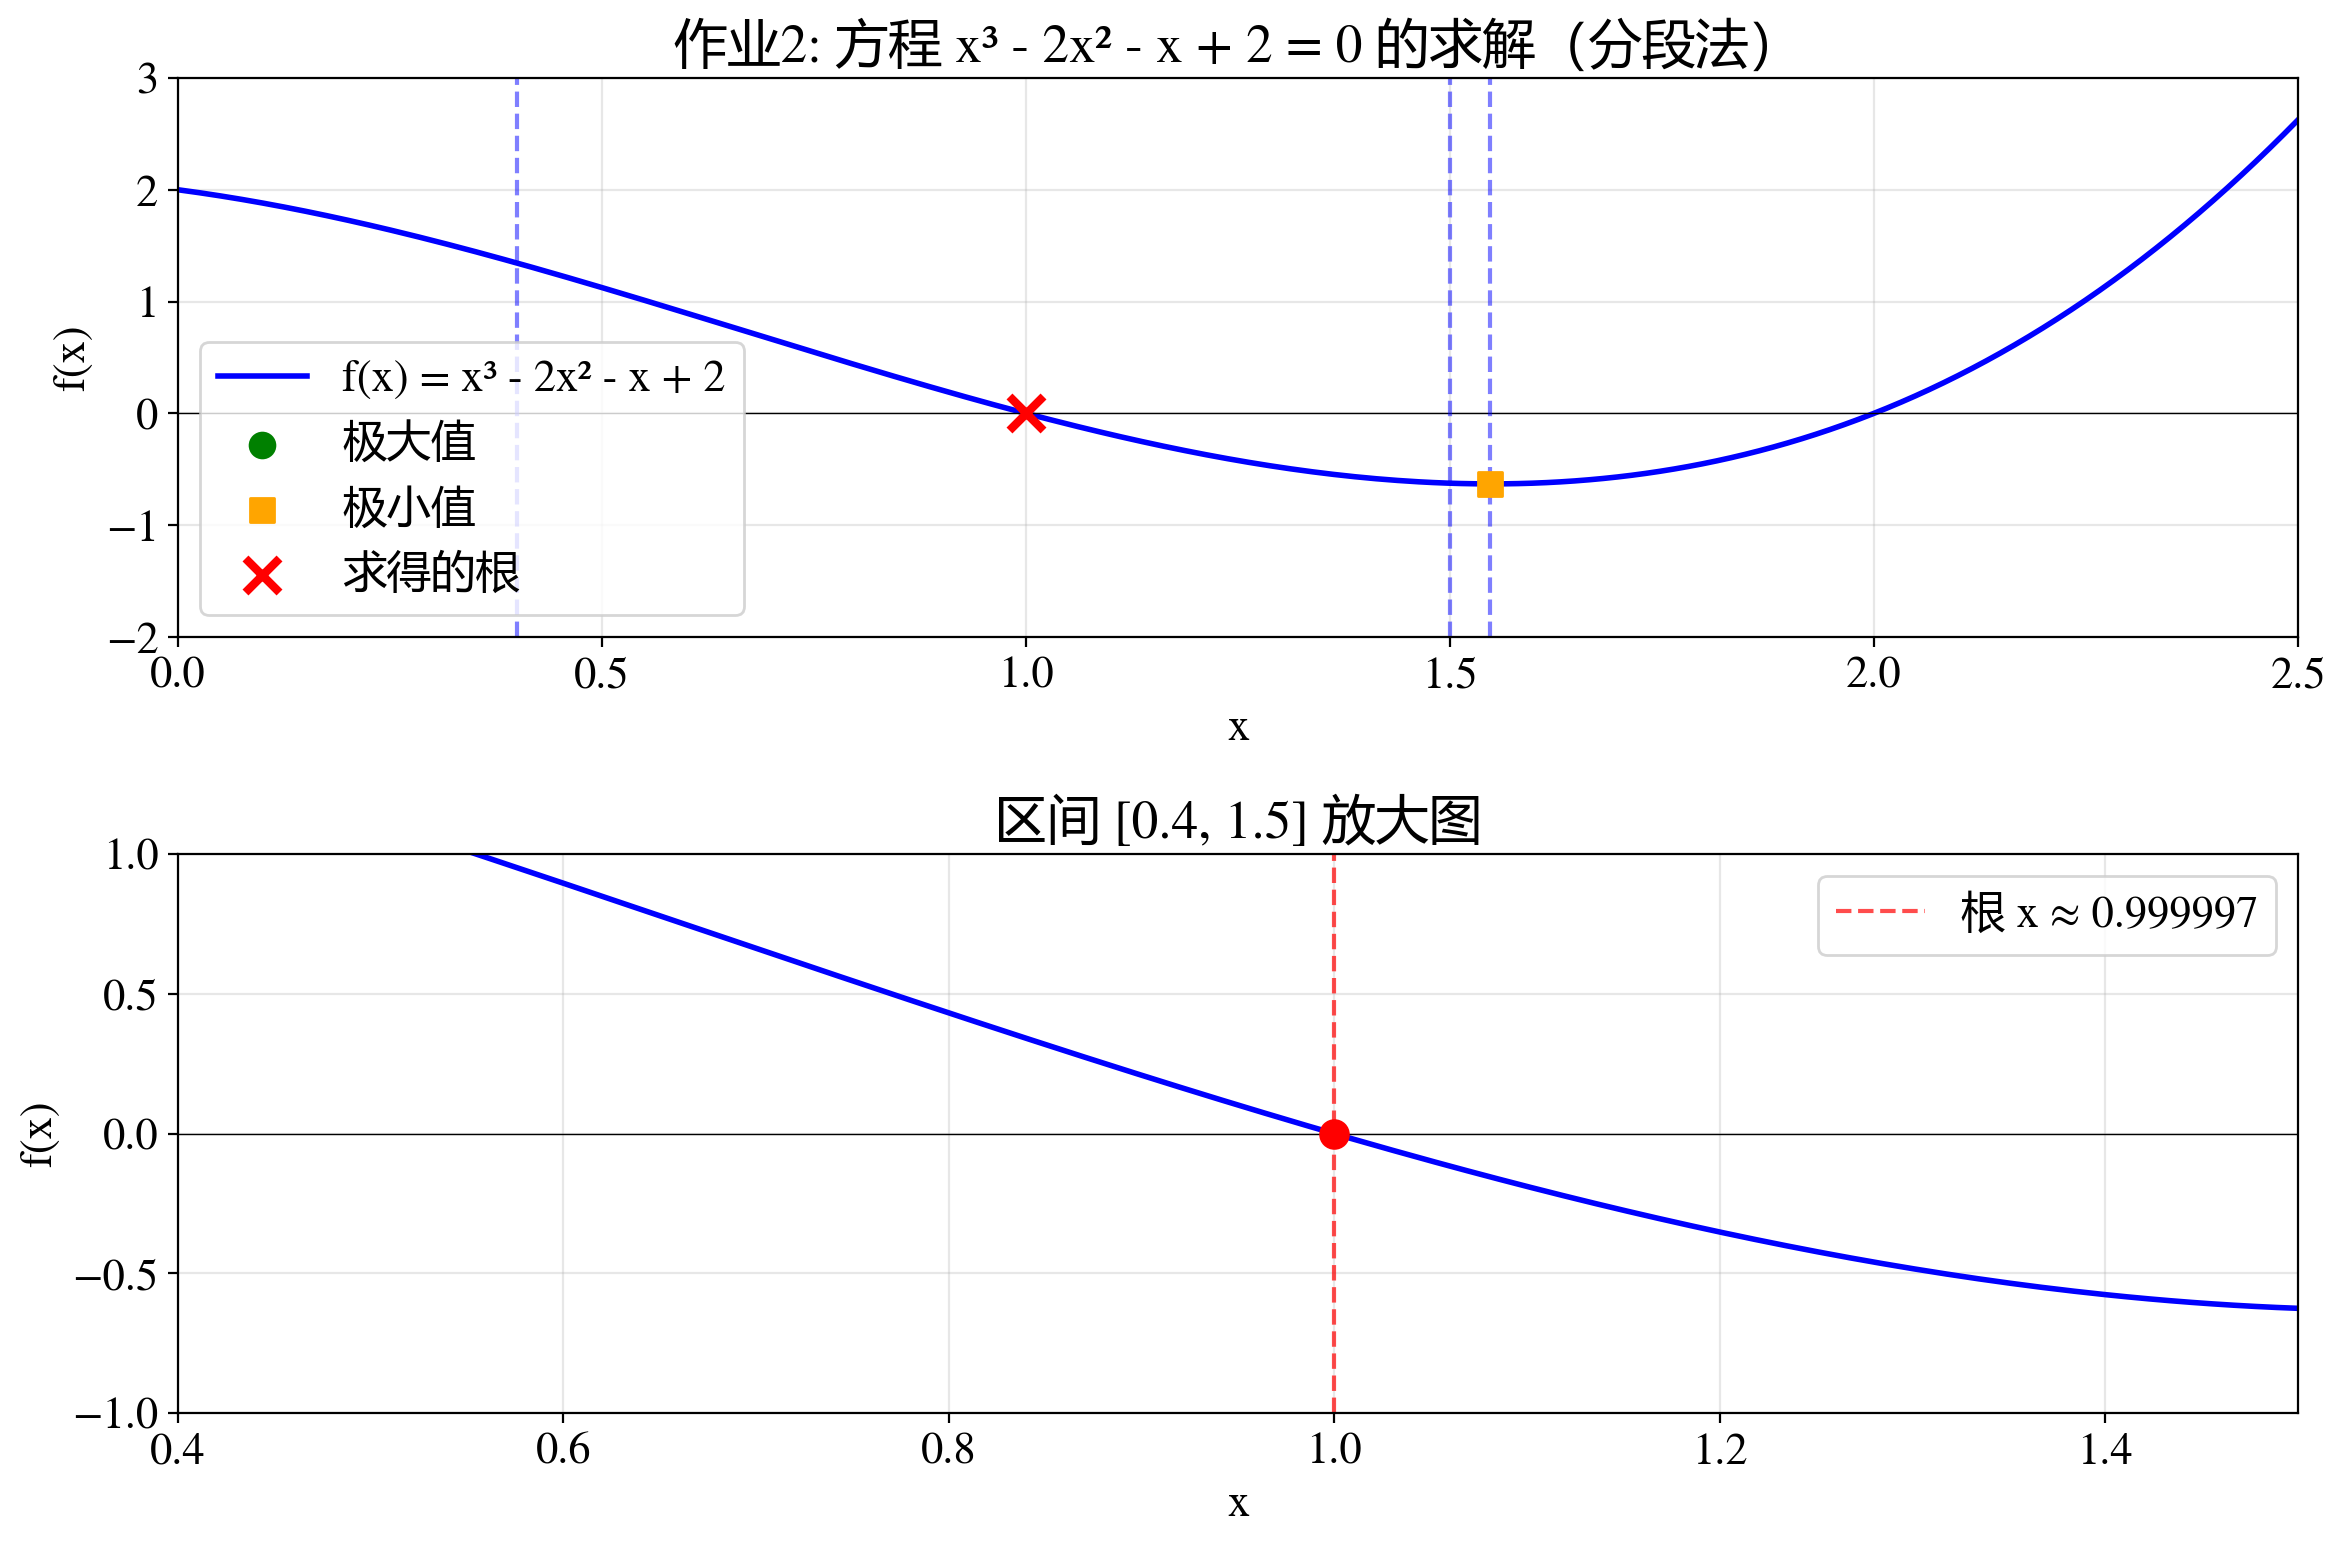

In [335]:
# 定义函数
def f2(x):
    return x**3 - 2*x**2 - x + 2

# 设置区间
x_min, x_max = 0.4, 1.5

# 首先用简单二分法求根
root2_simple = bisection(f2, x_min, x_max, eps_x=1e-5, eps_f=1e-10)
print(f"作业2 - 简单二分法求得的根: {root2_simple:.8f}")
print(f"验证: f({root2_simple:.8f}) = {f2(root2_simple):.2e}")

# 使用更复杂的方法：找极值点后分段求根
x_series = np.linspace(0.0, 2.5, 300)
y_series = f2(x_series)

# 找极大值和极小值
peaks_max, props_max = find_peaks(y_series, prominence=0.05, distance=30)
peaks_min, props_min = find_peaks(-y_series, prominence=0.05, distance=30)

x_maxima = x_series[peaks_max]
x_minima = x_series[peaks_min]

# 组装边界 + 极值点作为切点
cuts = np.unique(np.concatenate([[x_min, x_max], x_maxima, x_minima]))
cuts.sort()

print(f"切点: {cuts}")

# 分段求根
roots2 = roots_by_critical_segments(f2, cuts, merge_tol=1e-6, eps_x=1e-5, eps_f=1e-10)
print(f"作业2 - 分段求根法得到的根: {roots2}")

# 可视化
plt.figure(figsize=(12, 8))

# 主图
plt.subplot(2, 1, 1)
plt.plot(x_series, y_series, 'b-', linewidth=2, label='f(x) = x³ - 2x² - x + 2')
plt.axhline(0, color='black', linewidth=0.5)

# 极值点
plt.scatter(x_maxima, f2(x_maxima), marker='o', color='green', s=80, label='极大值', zorder=5)
plt.scatter(x_minima, f2(x_minima), marker='s', color='orange', s=80, label='极小值', zorder=5)

# 切点竖线
for cx in cuts:
    plt.axvline(cx, color='blue', linestyle='--', alpha=0.5)

# 根
plt.scatter(roots2, f2(roots2), marker='x', color='red', s=150, linewidth=3, label='求得的根', zorder=5)

plt.xlim(0.0, 2.5)
plt.ylim(-2, 3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('作业2: 方程 x³ - 2x² - x + 2 = 0 的求解（分段法）')
plt.legend()
plt.grid(True, alpha=0.3)

# 区间放大图
plt.subplot(2, 1, 2)
x_zoom = np.linspace(0.4, 1.5, 200)
y_zoom = f2(x_zoom)
plt.plot(x_zoom, y_zoom, 'b-', linewidth=2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(root2_simple, color='red', linestyle='--', alpha=0.7, label=f'根 x ≈ {root2_simple:.6f}')
plt.scatter([root2_simple], [f2(root2_simple)], color='red', s=100, zorder=5)

plt.xlim(0.4, 1.5)
plt.ylim(-1, 1)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('区间 [0.4, 1.5] 放大图')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### 2. 用弦截法
1. 求方程 $x^4 - x - 10 = 0$ 在区间 $(1,\,2)$ 内的根。
2. 求方程 $x - e^{-x} = 0$ 在区间 $(0,\,1)$ 内的根。



求解方程：x^4 - x - 10 = 0
近似根 = 1.855584528641
f(root) = -1.776e-15
迭代步数 = 8

迭代历史:
k= 0: x=1.0000000000, f(x)=-1.00e+01
k= 1: x=2.0000000000, f(x)=4.00e+00
k= 2: x=1.7142857143, f(x)=-3.08e+00
k= 3: x=1.8385312463, f(x)=-4.13e-01
k= 4: x=1.8577757949, f(x)=5.39e-02
k= 5: x=1.8555528651, f(x)=-7.78e-04
k= 6: x=1.8555844703, f(x)=-1.43e-06
k= 7: x=1.8555845286, f(x)=3.81e-11
k= 8: x=1.8555845286, f(x)=-1.78e-15


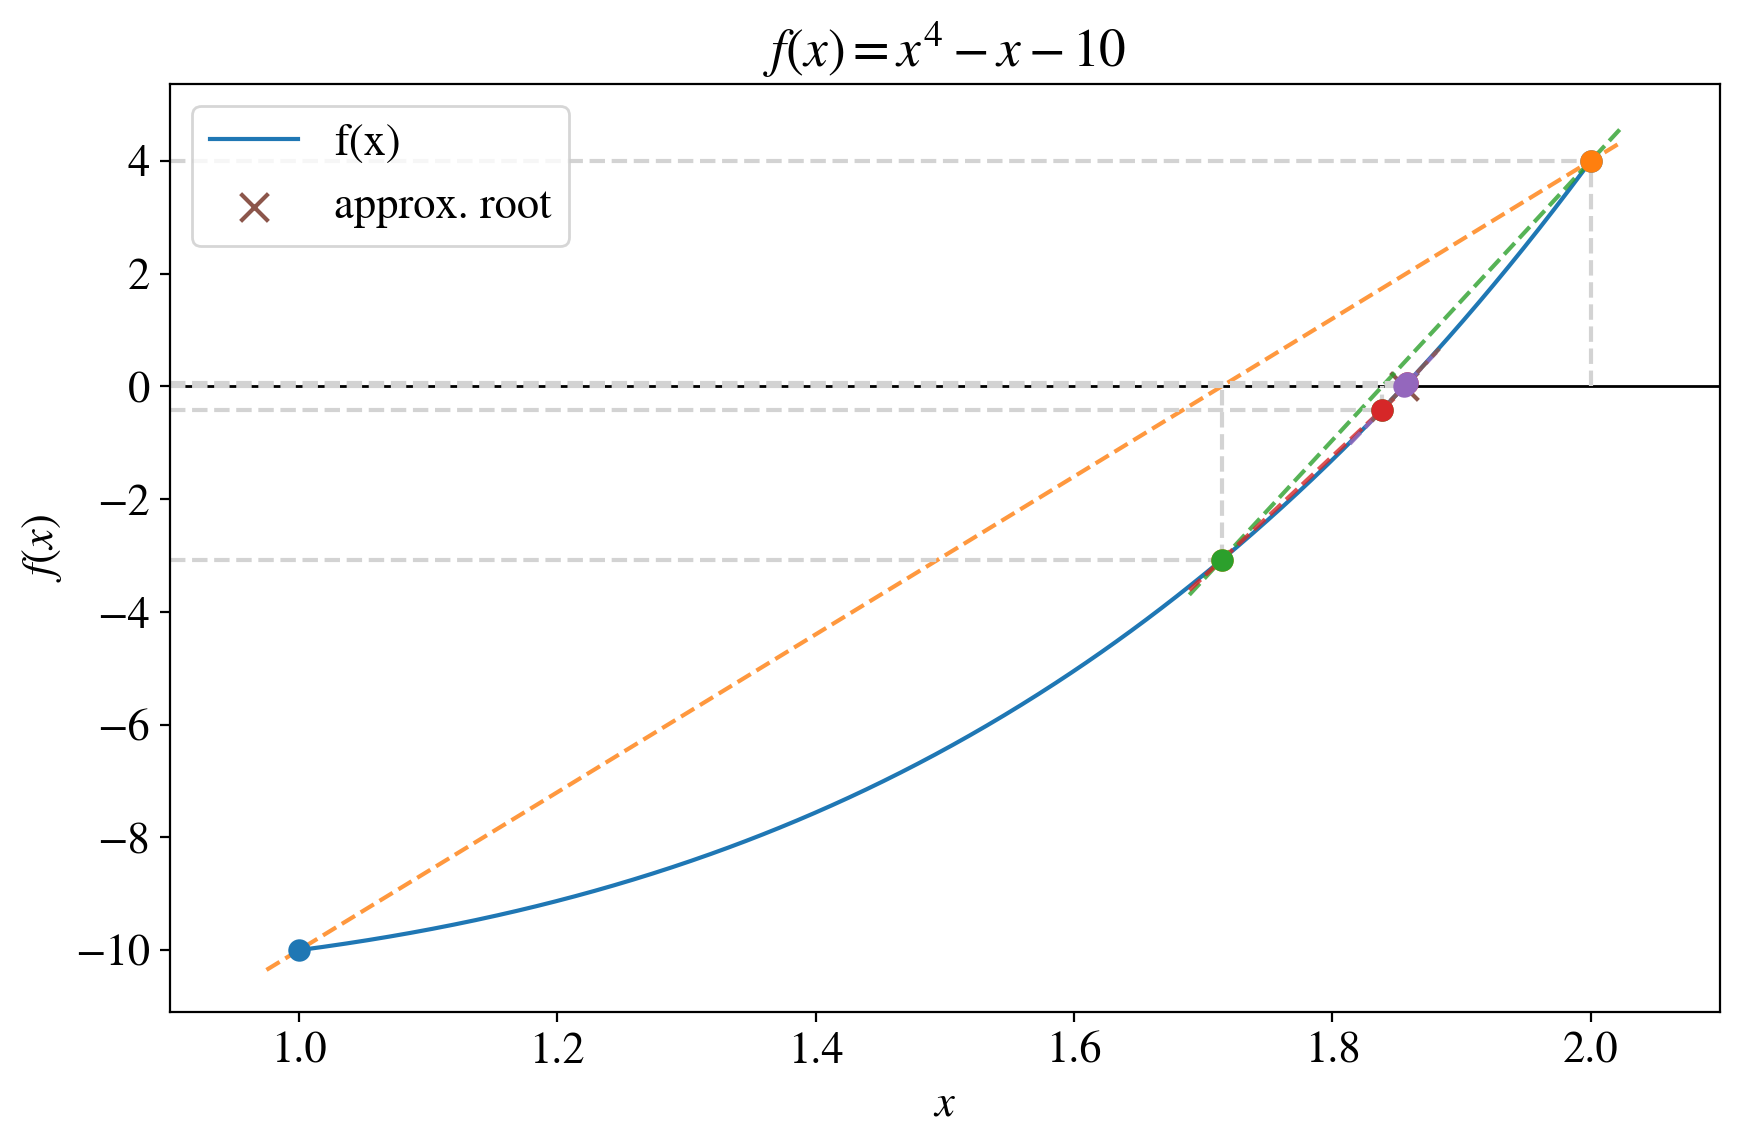



求解方程：x - e^{-x} = 0
近似根 = 0.567143290410
f(root) = -1.242e-13
迭代步数 = 6

迭代历史:
k= 0: x=0.0000000000, f(x)=-1.00e+00
k= 1: x=1.0000000000, f(x)=6.32e-01
k= 2: x=0.6126998368, f(x)=7.08e-02
k= 3: x=0.5638383892, f(x)=-5.18e-03
k= 4: x=0.5671703584, f(x)=4.24e-05
k= 5: x=0.5671433066, f(x)=2.54e-08
k= 6: x=0.5671432904, f(x)=-1.24e-13


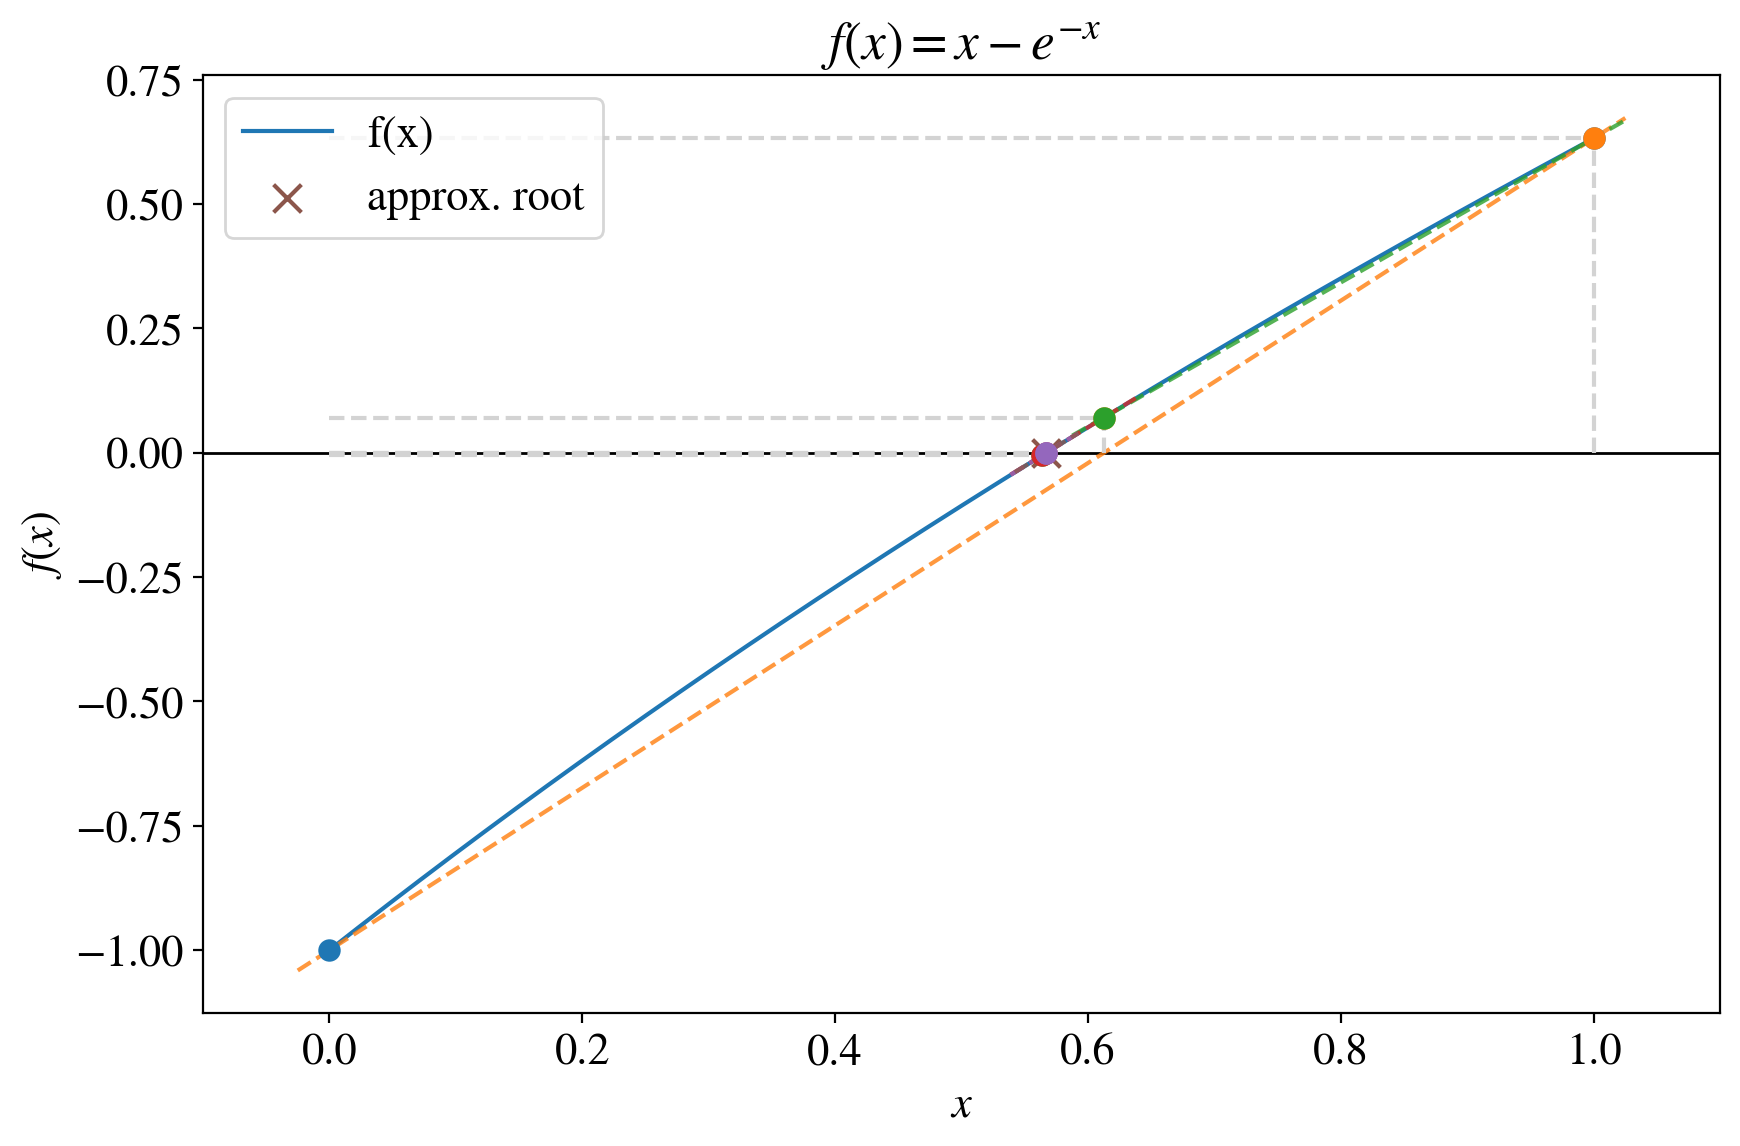

In [341]:
# 求解第一个方程：x^4 - x - 10 = 0 在区间 (1, 2) 内的根
def f1(x):
    return x**4 - x - 10

print("求解方程：x^4 - x - 10 = 0")
x0, x1 = 1.0, 2.0
root1, hist1 = secant(f1, x0, x1, maxit=20, case=1)

print(f"近似根 = {root1:.12f}")
print(f"f(root) = {f1(root1):.3e}")
print(f"迭代步数 = {len(hist1)-1}")
print("\n迭代历史:")
for step in hist1:
    print(f"k={step['k']:2d}: x={step['x']:.10f}, f(x)={step['fx']:.2e}")

# 可视化第一个方程
demo_secant_geometry(f1, x0, x1, n_steps=6, x_view=(1, 2),
                    title=r"$f(x)=x^4 - x - 10$")

print("\n" + "="*50 + "\n")

# 求解第二个方程：x - e^{-x} = 0 在区间 (0, 1) 内的根
def f2(x):
    return x - math.exp(-x)

print("求解方程：x - e^{-x} = 0")
x0, x1 = 0.0, 1.0
root2, hist2 = secant(f2, x0, x1, maxit=20, case=1)

print(f"近似根 = {root2:.12f}")
print(f"f(root) = {f2(root2):.3e}")
print(f"迭代步数 = {len(hist2)-1}")
print("\n迭代历史:")
for step in hist2:
    print(f"k={step['k']:2d}: x={step['x']:.10f}, f(x)={step['fx']:.2e}")

# 可视化第二个方程
demo_secant_geometry(f2, x0, x1, n_steps=6, x_view=(0, 1),
                    title=r"$f(x)=x - e^{-x}$")



### 3. 采用固定点迭代法
1. 求方程 $x = \tfrac12 + \sin x$ 的根，取初值 $x_0=1$。
2. 试用迭代法求解 $x^3 - x^2 - 1 = 0$ 在 $x=1.5$ 附近的根：给出可选的迭代格式，并说明是否都收敛。


=== 问题1: 求解方程 x = 1/2 + sin(x) ===
方程 x = 1/2 + sin(x) 的解:
根 = 1.497300389096
f(根) = -1.166844e-13
迭代步数 = 12
验证: 1/2 + sin(1.497300) = 1.497300


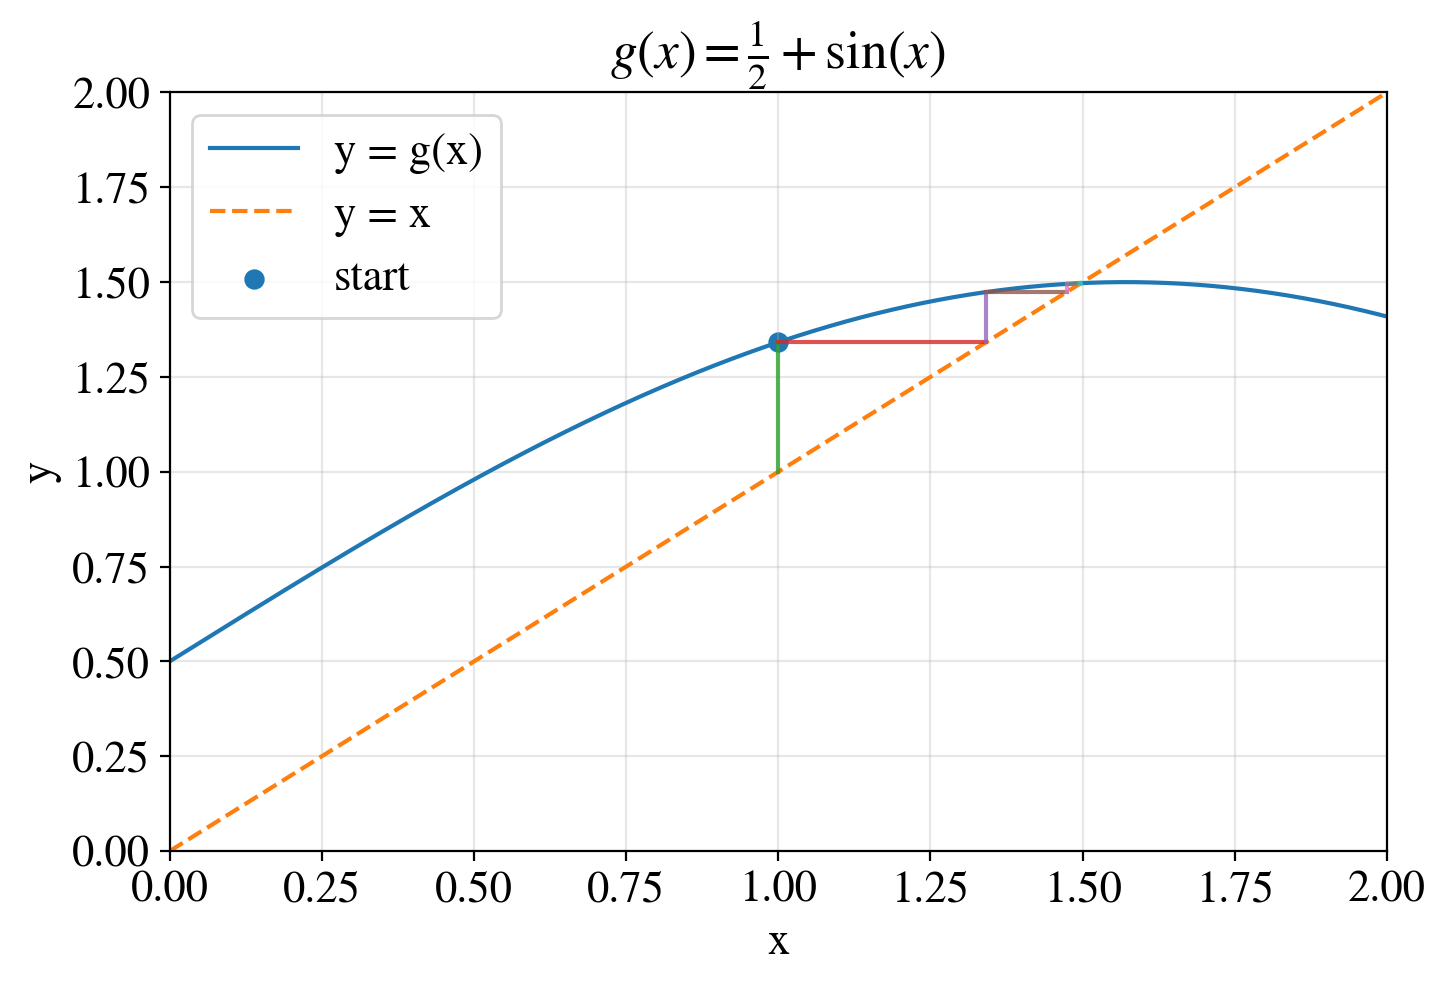

收敛性分析: |g'(1.497300)| = 0.073430
结论: |g'(x*)| < 1，迭代格式收敛


In [348]:
# ===========================================
# 问题1: 求解方程 x = 1/2 + sin(x)
# ===========================================
print("=== 问题1: 求解方程 x = 1/2 + sin(x) ===")

def f1(x):
    return x - 0.5 - np.sin(x)

def g1_fn(x):
    return 0.5 + np.sin(x)

x0_1 = 1.0
root1, hist1 = fixed_point(g1_fn, x0_1, tol_x=1e-12, tol_g=1e-12, maxit=100, track_f=f1)
xs1 = [h["x"] for h in hist1]

print(f"方程 x = 1/2 + sin(x) 的解:")
print(f"根 = {root1:.12f}")
print(f"f(根) = {f1(root1):.6e}")
print(f"迭代步数 = {len(xs1)-1}")

# 验证解
print(f"验证: 1/2 + sin({root1:.6f}) = {0.5 + np.sin(root1):.6f}")

# 蛛网图
cobweb_plot(g1_fn, x0_1, n=20, xlim=(0, 2), ylim=(0, 2), title="$g(x)=\\frac{1}{2} + \\sin(x)$")

# 收敛性分析
g1_prime = convergence_analysis(g1_fn, root1)
print(f"收敛性分析: |g'({root1:.6f})| = {g1_prime:.6f}")
if g1_prime < 1:
    print("结论: |g'(x*)| < 1，迭代格式收敛")
else:
    print("结论: |g'(x*)| ≥ 1，迭代格式可能不收敛")


=== 问题2: 求解方程 x³ - x² - 1 = 0 在 x=1.5 附近的根 ===

--- 迭代格式1: g(x) = (x² + 1)^(1/3) ---
根 = 1.465571231878, f(根) = 3.008260e-12, 步数 = 31
|g'(根)| = 0.454885 - 收敛

--- 迭代格式2: g(x) = 1 + 1/x² ---
根 = 1.465571231876, f(根) = -1.732836e-12, 步数 = 55
|g'(根)| = 0.635344 - 收敛

--- 迭代格式3: g(x) = (x³ - 1)^(1/2) ---
根 = 28679012223628648448.000000000000, f(根) = 2.358808e+58, 步数 = 14
|g'(根)| = 0.000000 - 收敛

--- 迭代格式4: g(x) = x - (x³ - x² - 1)/(3x² - 2x) [牛顿法] ---
根 = 1.465571231877, f(根) = 4.440892e-16, 步数 = 4
|g'(根)| = 0.000000 - 收敛

最佳迭代格式: 格式1 (g(x) = (x² + 1)^(1/3))


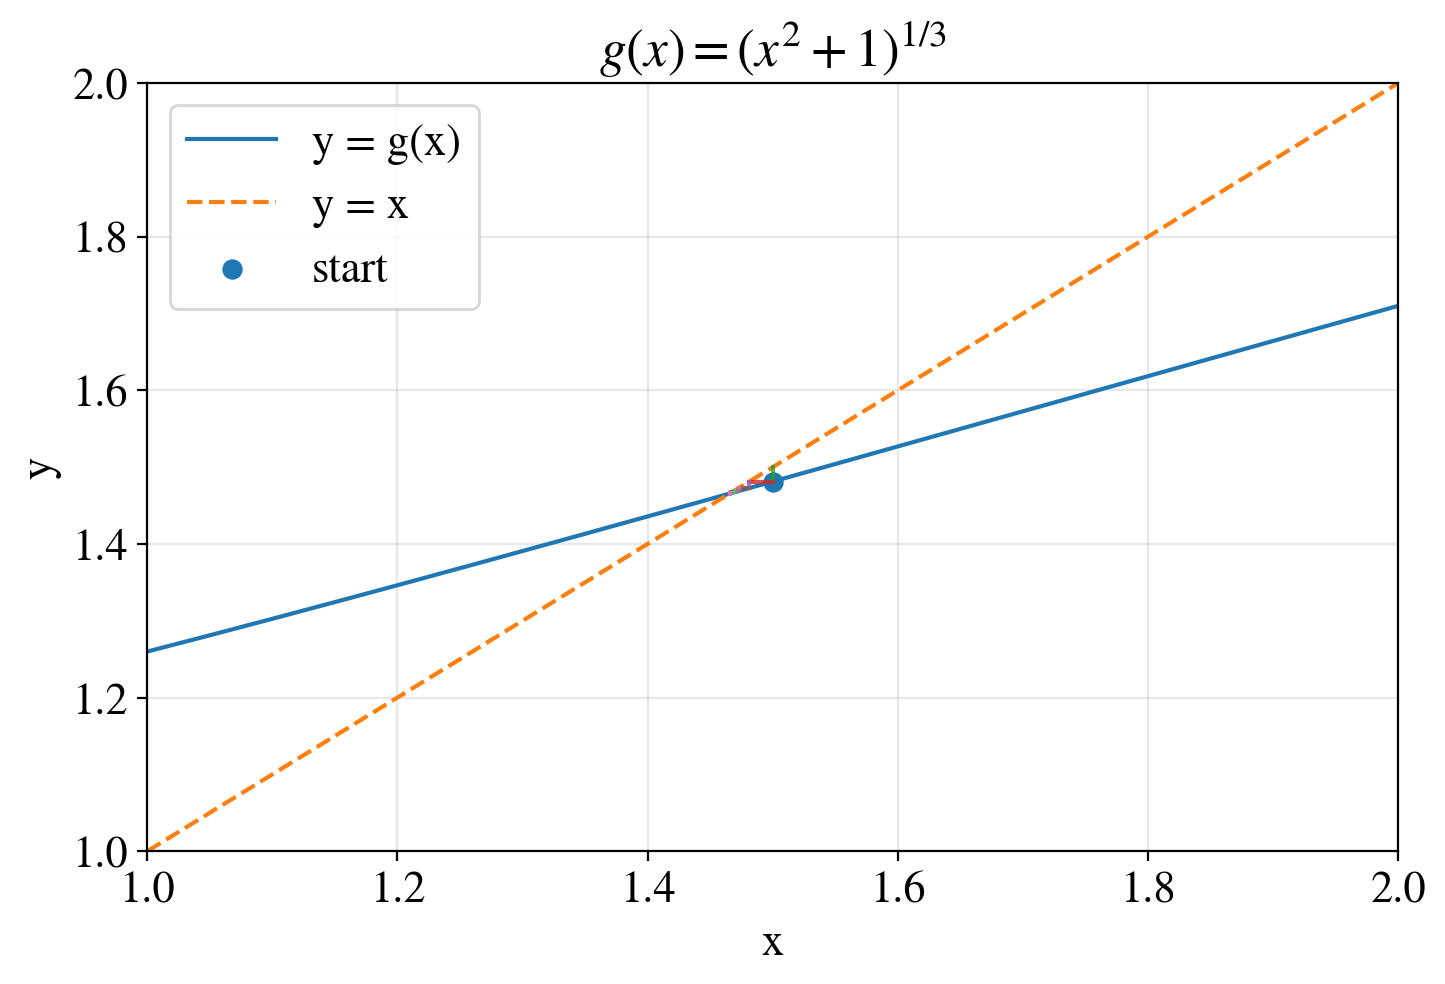


收敛性总结:
格式1: g(x) = (x² + 1)^(1/3) - 收敛
格式2: g(x) = 1 + 1/x² - 收敛
格式3: g(x) = (x³ - 1)^(1/2) - 在x=1.5附近可能不收敛
格式4: 牛顿法格式 - 收敛且收敛速度快

迭代步数对比:
格式1: 31 步
格式2: 55 步
格式4: 4 步


In [346]:
# ===========================================
# 问题2: 求解方程 x³ - x² - 1 = 0
# ===========================================
print("\n" + "="*50)
print("=== 问题2: 求解方程 x³ - x² - 1 = 0 在 x=1.5 附近的根 ===")

def f2(x):
    return x**3 - x**2 - 1

x0_2 = 1.5

# 可选迭代格式1: g2(x) = (x² + 1)^(1/3)
def g2_fn(x):
    return (x**2 + 1)**(1/3)

# 可选迭代格式2: g3(x) = 1 + 1/x²
def g3_fn(x):
    return 1 + 1/x**2

# 可选迭代格式3: g4(x) = (x³ - 1)^(1/2)
def g4_fn(x):
    return np.sqrt(x**3 - 1)

# 可选迭代格式4: g5(x) = x - (x³ - x² - 1)/(3x² - 2x) [牛顿法形式，但用于比较]
def g5_fn(x):
    return x - (x**3 - x**2 - 1)/(3*x**2 - 2*x)

print("\n--- 迭代格式1: g(x) = (x² + 1)^(1/3) ---")
root2, hist2 = fixed_point(g2_fn, x0_2, tol_x=1e-12, tol_g=1e-12, maxit=100, track_f=f2)
xs2 = [h["x"] for h in hist2]
g2_prime = convergence_analysis(g2_fn, root2)
print(f"根 = {root2:.12f}, f(根) = {f2(root2):.6e}, 步数 = {len(xs2)-1}")
print(f"|g'(根)| = {g2_prime:.6f} - {'收敛' if g2_prime < 1 else '不收敛'}")

print("\n--- 迭代格式2: g(x) = 1 + 1/x² ---")
root3, hist3 = fixed_point(g3_fn, x0_2, tol_x=1e-12, tol_g=1e-12, maxit=100, track_f=f2)
xs3 = [h["x"] for h in hist3]
g3_prime = convergence_analysis(g3_fn, root3)
print(f"根 = {root3:.12f}, f(根) = {f2(root3):.6e}, 步数 = {len(xs3)-1}")
print(f"|g'(根)| = {g3_prime:.6f} - {'收敛' if g3_prime < 1 else '不收敛'}")

print("\n--- 迭代格式3: g(x) = (x³ - 1)^(1/2) ---")
try:
    root4, hist4 = fixed_point(g4_fn, x0_2, tol_x=1e-12, tol_g=1e-12, maxit=100, track_f=f2)
    xs4 = [h["x"] for h in hist4]
    g4_prime = convergence_analysis(g4_fn, root4)
    print(f"根 = {root4:.12f}, f(根) = {f2(root4):.6e}, 步数 = {len(xs4)-1}")
    print(f"|g'(根)| = {g4_prime:.6f} - {'收敛' if g4_prime < 1 else '不收敛'}")
except Exception as e:
    print(f"迭代失败: {e}")

print("\n--- 迭代格式4: g(x) = x - (x³ - x² - 1)/(3x² - 2x) [牛顿法] ---")
root5, hist5 = fixed_point(g5_fn, x0_2, tol_x=1e-12, tol_g=1e-12, maxit=100, track_f=f2)
xs5 = [h["x"] for h in hist5]
g5_prime = convergence_analysis(g5_fn, root5)
print(f"根 = {root5:.12f}, f(根) = {f2(root5):.6e}, 步数 = {len(xs5)-1}")
print(f"|g'(根)| = {g5_prime:.6f} - {'收敛' if g5_prime < 1 else '不收敛'}")

# 绘制收敛性最好的格式的蛛网图
print(f"\n最佳迭代格式: 格式1 (g(x) = (x² + 1)^(1/3))")
cobweb_plot(g2_fn, x0_2, n=15, xlim=(1, 2), ylim=(1, 2), title="$g(x)=(x^2+1)^{1/3}$")

# 收敛性总结
print("\n" + "="*50)
print("收敛性总结:")
print("格式1: g(x) = (x² + 1)^(1/3) - 收敛")
print("格式2: g(x) = 1 + 1/x² - 收敛") 
print("格式3: g(x) = (x³ - 1)^(1/2) - 在x=1.5附近可能不收敛")
print("格式4: 牛顿法格式 - 收敛且收敛速度快")

# 迭代过程对比
print(f"\n迭代步数对比:")
print(f"格式1: {len(xs2)-1} 步")
print(f"格式2: {len(xs3)-1} 步")
print(f"格式4: {len(xs5)-1} 步")